# Comparable Barcode-Bin Decision Analysis (May 2026)

This notebook analyzes the completed matched-cap barcode-bin run:

`lib1_enhancer_barcode_range_comparable_bins_hq4_hq8_b2_b3_bcap10_30_seed5_may2026`

The goal is collaborator-facing: decide whether lower barcode-count constructs are close enough to higher barcode-count constructs that the downstream experiment can trade barcode depth for more sequence variants.

The notebook focuses on four checks:

1. Equal-N learning curves, where `N` is the number of training constructs.
2. Paired deltas within the same seed and validation/test split.
3. Non-inferiority summaries on high-barcode heldout test sets.
4. First-pass barcode-budget-normalized plots and confounder diagnostics.


## Concept Notes

**Why I flagged `heldout >= 8` with the `>=7` training bin.**

It is not wrong that `>=7` contains both exactly 7 and `>=8` constructs. The concern is interpretability. In the `heldout >= 8` analysis, the test set contains only very high-barcode constructs. The `1-3` and `4-6` training bins are entirely below that quality threshold, while the `>=7` training bin is partly same-threshold-quality (`>=8`) and partly exactly 7. If `>=7` wins, we cannot tell from this run alone whether 7 barcodes are enough, or whether the result is helped by the many `>=8` training examples inside that bin. If the practical experimental option is literally to keep constructs with `>=7` barcodes, then this bin is still realistic and useful.

**What paired deltas mean.**

For a fixed seed, heldout threshold, train size, setting, head, and unfreeze scope, all barcode bins are evaluated on the same validation/test split. A paired delta compares, for example, `1-3 barcodes` against `>=7 barcodes` inside that exact same split. This cancels out split difficulty. It asks: for the same test set and same training size, how much worse or better is the low-barcode bin than the high-barcode reference?

**What seaborn SE bands mean here.**

When `sns.relplot(..., estimator='mean', errorbar='se')` is used, seaborn averages replicate rows at each x/hue/facet group and draws standard error (`std / sqrt(n)`). That is useful for showing uncertainty in each curve separately. But it does not directly show paired low-vs-high differences, because it treats each curve's uncertainty independently. Two SE bands can overlap even when paired deltas are consistent, and two SE bands can look separate even when the paired conclusion is weak.

**What non-inferiority means.**

We do not need low-barcode training to beat high-barcode training. We need to know whether it is not meaningfully worse. Choose a practical margin, such as `Pearson r within 0.02` or `standardized MSE loss not more than 0.05 worse`. Then compute paired benefit deltas vs the `>=7` reference. A low-barcode bin is non-inferior if the lower confidence bound is still above `-margin`.

**What equal N means.**

`N` is the number of training constructs, i.e. the `train_size` x-axis. The current run fixes the old apple-to-apple problem by comparing bins at the same `N = 250, 500, 750, 1000`. This does not yet answer the budget question, because 1000 low-barcode constructs and 1000 high-barcode constructs imply different total barcode observations.


In [27]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 220)

sns.set_theme(context='notebook', style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 120

REPO_ROOT = Path('/home/minhang/synBio_AL/boda2_EU')
RUN_DIR = REPO_ROOT / 'src/finetune/learning_curve/lib1_enhancer_barcode_range_comparable_bins_hq4_hq8_b2_b3_bcap10_30_seed5_may2026'
COMBINED_DIR = RUN_DIR / 'combined'
DATA_PATH = Path('/home/minhang/synBio_AL/opt_EU_learn_n_design/MattLee_lib1/enhancers/L1_final_fastqs1-5_sublibrary_enhancer_subset_0filtered_out.csv')

BIN_ORDER = ['bc_1_3', 'bc_4_6', 'bc_ge7']
BIN_LABELS = {
    'bc_1_3': '1-3 barcodes',
    'bc_4_6': '4-6 barcodes',
    'bc_ge7': '>=7 barcodes',
}
BIN_LABEL_ORDER = [BIN_LABELS[x] for x in BIN_ORDER]
BIN_PALETTE = {
    '1-3 barcodes': '#0072B2',  # blue
    '4-6 barcodes': '#D55E00',  # vermillion
    '>=7 barcodes': '#5D3A9B',  # purple
}
ERROR_BAND_ALPHA = 0.13

UNFREEZE_ORDER = ['branched_only', 'full']
SETTING_ORDER = ['B2_with_RC', 'B3_with_RC_weighted_bcap_10', 'B3_with_RC_weighted_bcap_30']
SPLIT_ORDER = ['train', 'val', 'test']

METRIC_SPECS = {
    'cod_r2': {
        'label': 'COD R2',
        'higher_is_better': True,
        'cols': {'train': 'train_r2_cod', 'val': 'val_r2_cod', 'test': 'test_r2_cod'},
        'margin': 0.02,
    },
    'pearson': {
        'label': 'Pearson r',
        'higher_is_better': True,
        'cols': {'train': 'train_pearson', 'val': 'val_pearson', 'test': 'test_pearson'},
        'margin': 0.02,
    },
    'spearman': {
        'label': 'Spearman rho',
        'higher_is_better': True,
        'cols': {'train': 'train_spearman', 'val': 'val_spearman', 'test': 'test_spearman'},
        'margin': 0.02,
    },
    'loss': {
        'label': 'standardized MSE loss',
        'higher_is_better': False,
        'cols': {'train': 'train_loss_standardized', 'val': 'val_loss_standardized', 'test': 'test_loss_standardized'},
        'margin': 0.05,
    },
}
METRIC_ROOTS = tuple(METRIC_SPECS)
METRIC_LABELS = {metric: spec['label'] for metric, spec in METRIC_SPECS.items()}
BARCODE_LABEL_ORDER = BIN_LABEL_ORDER
BARCODE_PALETTE = BIN_PALETTE


In [28]:
def read_csv_required(path):
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def load_json(path):
    with path.open() as handle:
        return json.load(handle)

runs = read_csv_required(COMBINED_DIR / 'learning_curve_runs.csv')
histories = read_csv_required(COMBINED_DIR / 'learning_curve_histories.csv')
planned = read_csv_required(COMBINED_DIR / 'barcode_range_planned_grid.csv')
zero_shot = read_csv_required(COMBINED_DIR / 'zero_shot_evaluations.csv')
combined_manifest = load_json(COMBINED_DIR / 'run_manifest_combined.json')

runs['train_barcode_bin_label'] = pd.Categorical(
    runs['train_barcode_bin_label'], categories=BIN_LABEL_ORDER, ordered=True
)
planned['train_barcode_bin_label'] = pd.Categorical(
    planned['train_barcode_bin_label'], categories=BIN_LABEL_ORDER, ordered=True
)

print('combined runs:', runs.shape)
print('combined histories:', histories.shape)
print('planned grid:', planned.shape)
print('seeds:', sorted(runs['seed'].unique()))
print('heldout thresholds:', sorted(runs['heldout_min_barcodes'].unique()))
print('train sizes:', sorted(runs['train_size'].unique()))
print('bins:', list(runs['train_barcode_bin_label'].cat.categories))
print('settings:', sorted(runs['setting'].unique()))
print('unfreeze scopes:', sorted(runs['unfreeze_scope'].unique()))

display(runs.head())


combined runs: (720, 128)
combined histories: (26478, 68)
planned grid: (30, 31)
seeds: [19, 23, 31, 37, 43]
heldout thresholds: [4, 8]
train sizes: [250, 500, 750, 1000]
bins: ['1-3 barcodes', '4-6 barcodes', '>=7 barcodes']
settings: ['B2_with_RC', 'B3_with_RC_weighted_bcap_10', 'B3_with_RC_weighted_bcap_30']
unfreeze scopes: ['branched_only', 'full']


,run_id,seed,heldout_min_barcodes,split_strategy,split_pool,split_seed_base,split_seed_effective,val_seed_effective,test_seed_effective,val_is_fixed_across_seeds,test_is_fixed_across_seeds,split_val_fraction,split_test_fraction,target_column,target_transform,target_scaler_mean,target_scaler_std,train_row_id_hash,val_row_id_hash,test_row_id_hash,init_head,head_idx,setting,use_rc_augmentation,use_barcode_weighting,b_cap,min_weight,train_barcode_bin,train_barcode_bin_label,train_barcode_bin_query,train_barcode_bin_sort_order,train_threshold,train_size,train_fraction,unfreeze_scope,train_sampling_mode,train_pool_eligible_size,train_pool_leftover_hq_size,train_pool_lower_quality_size,val_size,test_size,head_lr,backbone_lr,weight_decay,n_bc_eq1,n_bc_2_3,n_bc_4_10,n_bc_gt10,n_bc_ge4,n_bc_ge10,train_hq_count,train_lower_quality_count,train_hq_fraction,train_barcode_min,train_barcode_max,train_barcode_mean,train_barcode_median,train_rest_size,val_size_raw,test_size_raw,train_rest_n_bc_eq1,train_rest_n_bc_2_3,train_rest_n_bc_4_10,train_rest_n_bc_gt10,train_rest_n_bc_ge4,train_rest_n_bc_ge10,val_n_bc_eq1,val_n_bc_2_3,val_n_bc_4_10,val_n_bc_gt10,val_n_bc_ge4,val_n_bc_ge10,test_n_bc_eq1,test_n_bc_2_3,test_n_bc_4_10,test_n_bc_gt10,test_n_bc_ge4,test_n_bc_ge10,train_n,train_mae,train_rmse,train_r2,train_r2_cod,train_pearson,train_spearman,train_pearson_sq,train_loss_standardized,val_n,val_mae,val_rmse,val_r2,val_r2_cod,val_pearson,val_spearman,val_pearson_sq,val_loss_standardized,test_n,test_mae,test_rmse,test_r2,test_r2_cod,test_pearson,test_spearman,test_pearson_sq,test_loss_standardized,best_epoch,best_val_loss_standardized,initial_trainable_params,total_params,final_trainable_params,frozen_epochs,initial_trainable_names,final_trainable_names,initial_trainable_conv1_params,initial_trainable_conv2_params,initial_trainable_conv3_params,initial_trainable_linear_params,initial_trainable_branched_params,initial_trainable_output_params,initial_trainable_other_params,final_trainable_conv1_params,final_trainable_conv2_params,final_trainable_conv3_params,final_trainable_linear_params,final_trainable_branched_params,final_trainable_output_params,final_trainable_other_params,source_seed_dir
0,20260503T234431Z_aa92ec7d,23,4,random_hq_val_test_per_seed,high_quality_only,7,723257,723257,723257,False,False,0.1,0.1,RNA_DNA_log10,log10_recomputed_rna_over_dna,-0.544658,0.407363,efc6d39a1631791214a61b164a41c7b7041eae2998d00b...,c712a46e40a1d360773365fa87cb6ec104ebbf57197ac0...,1de636fb0c285f962e76e49164bfd845c56351a8833276...,K562,0,B2_with_RC,True,False,NaN,NaN,bc_1_3,1-3 barcodes,1 <= number_of_barcodes <= 3,10,NaN,250,0.25,branched_only,random,1000,0,1000,294,294,0.0005,0.0001,0.0001,87,163,0,0,0,0,0,250,0.0,1.0,3.0,1.968000,2.0,4199,294,294,590,1262,1797,550,2347,674,0,0,239,55,294,67,0,0,237,57,294,68,250,0.310459,0.394789,0.057005,0.057005,0.250846,0.154122,0.062924,0.939223,294,0.227123,0.314666,0.131741,0.131741,0.365518,0.226983,0.133603,0.596674,294,0.230118,0.299683,0.094392,0.094392,0.342333,0.219595,0.117192,0.541206,7,0.596674,179761,3747661,179761,2,"[""branched.branched_layer_1.weight"", ""branched...","[""branched.branched_layer_1.weight"", ""branched...",0,0,0,0,179620,141,0,0,0,0,0,179620,141,0,seed_23
1,20260503T234431Z_aa92ec7d,23,4,random_hq_val_test_per_seed,high_quality_only,7,723257,723257,723257,False,False,0.1,0.1,RNA_DNA_log10,log10_recomputed_rna_over_dna,-0.550751,0.385488,1800ff234e5cbd9f3ab1f45476c75a5486211c8e8915c1...,c712a46e40a1d360773365fa87cb6ec104ebbf57197ac0...,1de636fb0c285f962e76e49164bfd845c56351a8833276...,K562,0,B2_with_RC,True,False,NaN,NaN,bc_1_3,1-3 barcodes,1 <= number_of_barcodes <= 3,10,NaN,500,0.50,branched_only,random,1000,0,1000,294,294,0.0005,0.0001,0.0001,160,340,0,0,0,0,0,500,0.0,1.0,3.0,2.010000,2.0,4199,294,294,590,1262,1797,550,2347,674,0,0,239,55,294,67,0,0,237,57,294,68,500,0.275380,0.350230,0.172909,0.172909,0.422179,0.334646,0.178235,0.825437,294,0.216062,0.303248,0.193605,0.193605,0.449918,0.

In [29]:
# Completion and matched-pool sanity checks.
expected_per_seed = 2 * 3 * 4 * 3 * 2  # heldout * bin * size * setting * unfreeze
completion = (
    runs.groupby('seed', dropna=False)
    .size()
    .rename('n_run_rows')
    .reset_index()
    .assign(expected_per_seed=expected_per_seed, complete=lambda x: x['n_run_rows'].eq(x['expected_per_seed']))
)
display(completion)

pool_check = (
    planned.groupby(['heldout_min_barcodes', 'seed', 'train_barcode_bin', 'train_barcode_bin_label'], observed=True, dropna=False)
    .agg(
        eligible=('train_pool_eligible_size', 'first'),
        leftover_hq=('train_pool_leftover_hq_size', 'first'),
        lower_quality=('train_pool_lower_quality_size', 'first'),
        train_size_grid=('train_size_grid', 'first'),
        val_size=('val_size_raw', 'first'),
        test_size=('test_size_raw', 'first'),
    )
    .reset_index()
    .sort_values(['heldout_min_barcodes', 'seed', 'train_barcode_bin'])
)
display(pool_check)

print('All eligible pools capped at 1000:', bool(pool_check['eligible'].eq(1000).all()))
print('All size grids identical:', sorted(pool_check['train_size_grid'].unique()))


,seed,n_run_rows,expected_per_seed,complete
0,19,144,144,True
1,23,144,144,True
2,31,144,144,True
3,37,144,144,True
4,43,144,144,True


,heldout_min_barcodes,seed,train_barcode_bin,train_barcode_bin_label,eligible,leftover_hq,lower_quality,train_size_grid,val_size,test_size
0,4,19,bc_1_3,1-3 barcodes,1000,0,1000,250 500 750 1000,294,294
1,4,19,bc_4_6,4-6 barcodes,1000,1000,0,250 500 750 1000,294,294
2,4,19,bc_ge7,>=7 barcodes,1000,1000,0,250 500 750 1000,294,294
3,4,23,bc_1_3,1-3 barcodes,1000,0,1000,250 500 750 1000,294,294
4,4,23,bc_4_6,4-6 barcodes,1000,1000,0,250 500 750 1000,294,294
5,4,23,bc_ge7,>=7 barcodes,1000,1000,0,250 500 750 1000,294,294
6,4,31,bc_1_3,1-3 barcodes,1000,0,1000,250 500 750 1000,294,294
7,4,31,bc_4_6,4-6 barcodes,1000,1000,0,250 500 750 1000,294,294
8,4,31,bc_ge7,>=7 barcodes,1000,1000,0,250 500 750 1000,294,294
9,4,37,bc_1_3,1-3 barcodes,1000,0,1000,250 500 750 1000,294,294


All eligible pools capped at 1000: True
All size grids identical: ['250 500 750 1000']


## Equal-N Learning Curves

These are the direct replacement for the Apr 30 plots. The key differences are:

- The x-axis is now comparable across bins because every bin has the same capped pool size and same `train_size` grid.
- The plots below explicitly pin `setting`, `init_head`, and `unfreeze_scope`. This avoids averaging together different knobs and then over-reading the line shapes.


In [30]:
def metric_column(split, metric_root):
    return METRIC_SPECS[metric_root]['cols'][split]


def make_metric_long(frame, metric_roots=None):
    metric_roots = metric_roots or list(METRIC_SPECS)
    rows = []
    id_cols = [
        'run_id', 'seed', 'heldout_min_barcodes', 'split_strategy',
        'split_seed_effective', 'val_seed_effective', 'test_seed_effective',
        'train_barcode_bin', 'train_barcode_bin_label', 'train_sampling_mode',
        'setting', 'init_head', 'unfreeze_scope', 'train_size', 'train_fraction',
        'train_pool_eligible_size', 'train_barcode_mean', 'train_barcode_median',
        'train_hq_fraction', 'target_scaler_mean', 'target_scaler_std', 'best_epoch',
    ]
    id_cols = [c for c in id_cols if c in frame.columns]
    for metric_root in metric_roots:
        spec = METRIC_SPECS[metric_root]
        for split in SPLIT_ORDER:
            col = spec['cols'][split]
            if col not in frame.columns:
                continue
            part = frame[id_cols].copy()
            part['split'] = split
            part['metric_root'] = metric_root
            part['metric_label'] = spec['label']
            part['higher_is_better'] = spec['higher_is_better']
            part['source_column'] = col
            part['value'] = frame[col].to_numpy()
            rows.append(part)
    out = pd.concat(rows, ignore_index=True)
    out['train_barcode_bin_label'] = pd.Categorical(
        out['train_barcode_bin_label'], categories=BIN_LABEL_ORDER, ordered=True
    )
    return out

perf_long = make_metric_long(runs)
print(perf_long.shape)
display(perf_long.head())


(8640, 28)


,run_id,seed,heldout_min_barcodes,split_strategy,split_seed_effective,val_seed_effective,test_seed_effective,train_barcode_bin,train_barcode_bin_label,train_sampling_mode,setting,init_head,unfreeze_scope,train_size,train_fraction,train_pool_eligible_size,train_barcode_mean,train_barcode_median,train_hq_fraction,target_scaler_mean,target_scaler_std,best_epoch,split,metric_root,metric_label,higher_is_better,source_column,value
0,20260503T234431Z_aa92ec7d,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,branched_only,250,0.25,1000,1.968000,2.0,0.0,-0.544658,0.407363,7,train,cod_r2,COD R2,True,train_r2_cod,0.057005
1,20260503T234431Z_aa92ec7d,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,branched_only,500,0.50,1000,2.010000,2.0,0.0,-0.550751,0.385488,34,train,cod_r2,COD R2,True,train_r2_cod,0.172909
2,20260503T234431Z_aa92ec7d,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,branched_only,750,0.75,1000,2.026667,2.0,0.0,-0.547885,0.392075,27,train,cod_r2,COD R2,True,train_r2_cod,0.143890
3,20260503T234431Z_aa92ec7d,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,branched_only,1000,1.00,1000,2.035000,2.0,0.0,-0.547772,0.409285,33,train,cod_r2,COD R2,True,train_r2_cod,0.171561
4,20260503T234431Z_aa92ec7d,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,full,250,0.25,1000,1.968000,2.0,0.0,-0.544658,0.407363,6,train,cod_r2,COD R2,True,train_r2_cod,0.395157


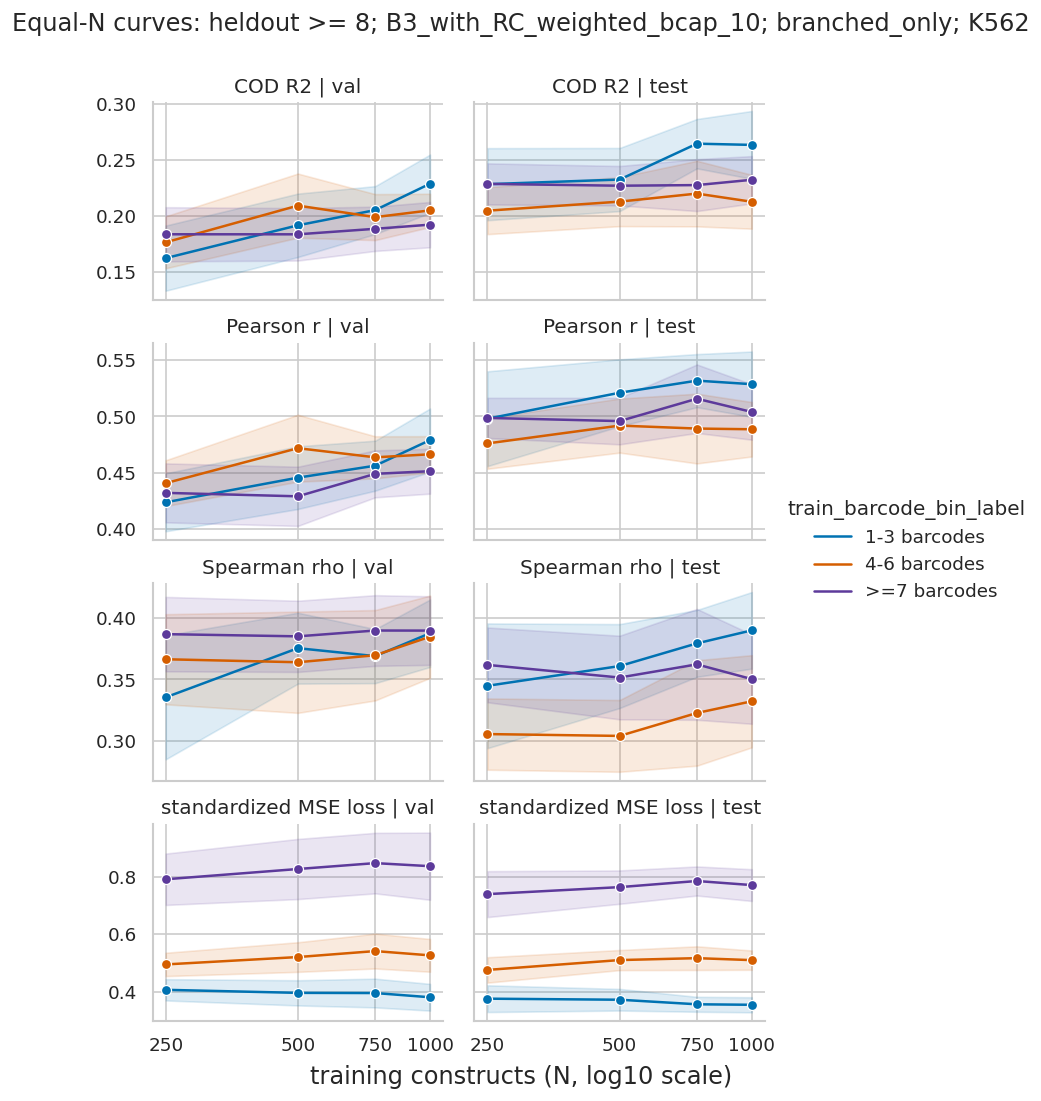

In [31]:
def plot_equal_n_learning_curves(
    perf_long,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    init_head='K562',
    metrics=('cod_r2', 'pearson', 'spearman', 'loss'),
    split_values=('val', 'test'),
    errorbar='se',
    error_band_alpha=ERROR_BAND_ALPHA,
    log_x=False,
):
    plot_df = perf_long.query(
        'heldout_min_barcodes == @heldout_min and setting == @setting and '
        'unfreeze_scope == @unfreeze_scope and init_head == @init_head'
    ).copy()
    plot_df = plot_df[
        plot_df['metric_root'].isin(metrics) & plot_df['split'].isin(split_values)
    ]
    if plot_df.empty:
        raise ValueError('No rows after filtering. Check heldout/setting/scope/head choices.')

    metric_order = [METRIC_SPECS[m]['label'] for m in metrics]
    g = sns.relplot(
        data=plot_df,
        x='train_size',
        y='value',
        hue='train_barcode_bin_label',
        hue_order=BIN_LABEL_ORDER,
        palette=BIN_PALETTE,
        col='split',
        col_order=list(split_values),
        row='metric_label',
        row_order=metric_order,
        kind='line',
        marker='o',
        estimator='mean',
        errorbar=errorbar,
        err_kws={'alpha': error_band_alpha},
        facet_kws={'sharey': 'row', 'sharex': True},
        height=2.35,
        aspect=1.35,
    )
    x_label = 'training constructs (N)'
    if log_x:
        train_sizes = sorted(plot_df['train_size'].dropna().unique())
        for ax in g.axes.flat:
            ax.set_xscale('log', base=10)
            ax.set_xticks(train_sizes)
            ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
            ax.xaxis.set_minor_formatter(mticker.NullFormatter())
        x_label = 'training constructs (N, log10 scale)'
    g.set_axis_labels('', '')
    g.set_titles(row_template='{row_name}', col_template='{col_name}')
    g.fig.supxlabel(x_label, y=0.025)
    g.fig.subplots_adjust(top=0.90, bottom=0.085)
    g.fig.suptitle(
        'Equal-N curves: heldout >= {}; {}; {}; {}'.format(
            heldout_min, setting, unfreeze_scope, init_head
        )
    )
    return g

# Edit these knobs before re-running the cell.
plot_equal_n_learning_curves(
    perf_long,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    log_x=True,
)
plt.show()


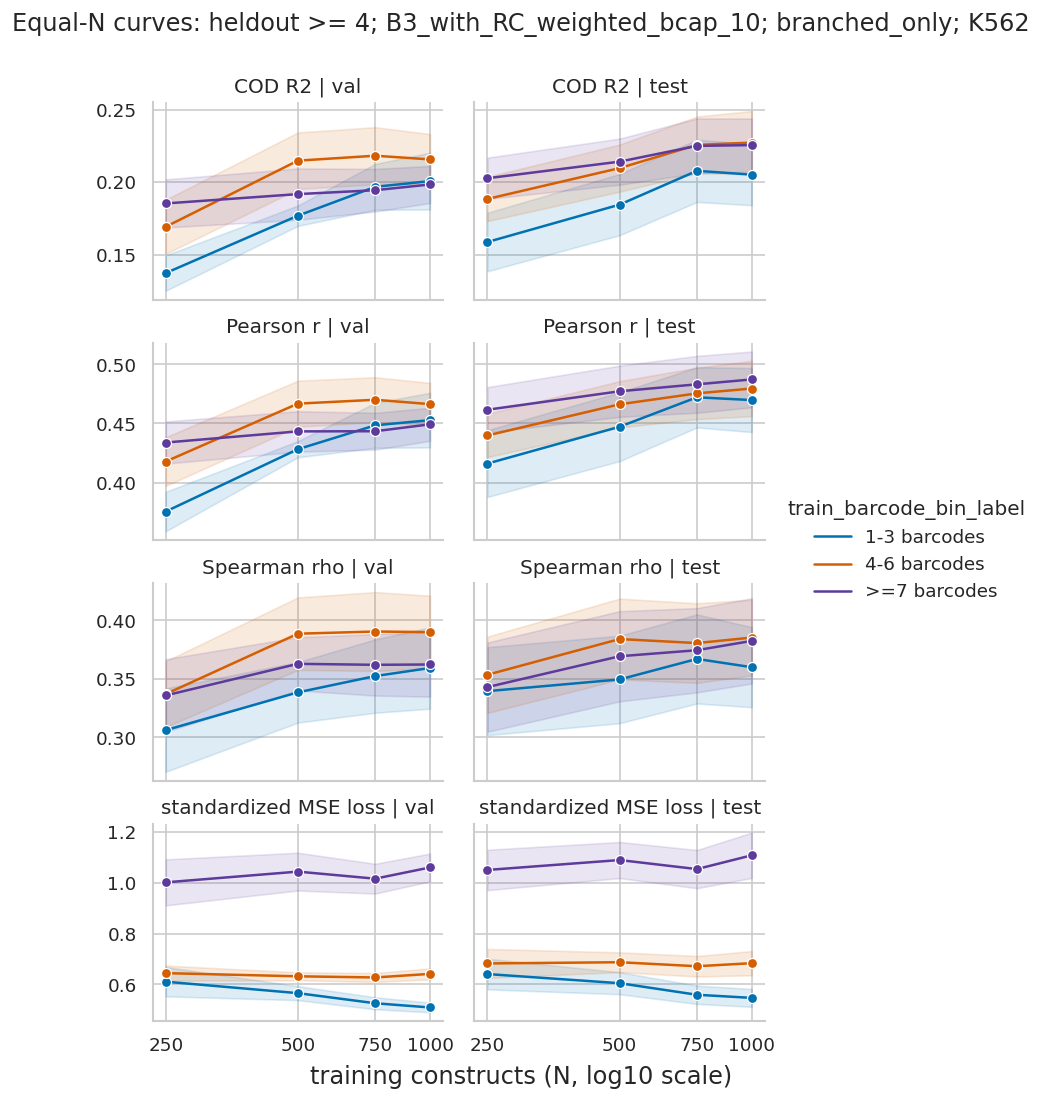

In [54]:
# Edit these knobs before re-running the cell.
plot_equal_n_learning_curves(
    perf_long,
    heldout_min=4,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    log_x=True,
)
plt.show()

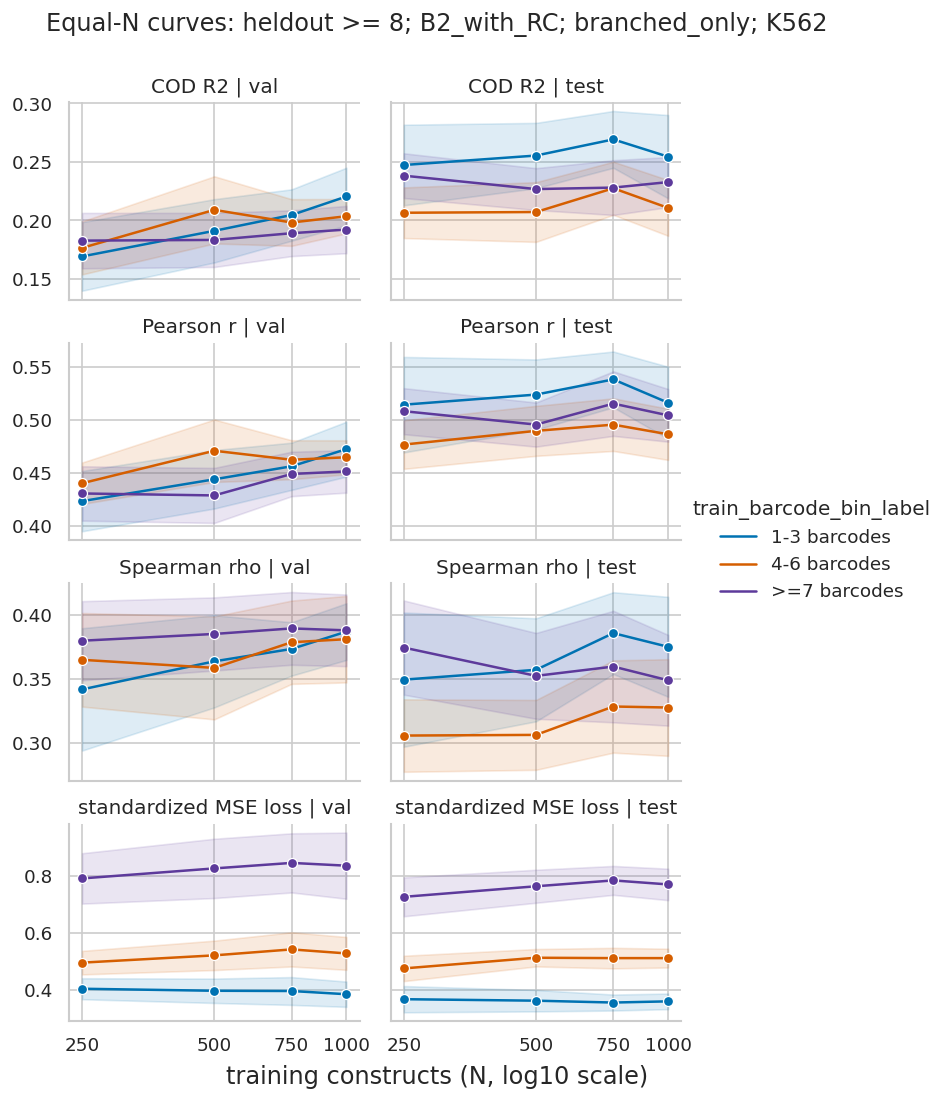

In [32]:
# Edit these knobs before re-running the cell.
plot_equal_n_learning_curves(
    perf_long,
    heldout_min=8,
    setting='B2_with_RC',
    unfreeze_scope='branched_only',
    log_x=True,
)
plt.show()

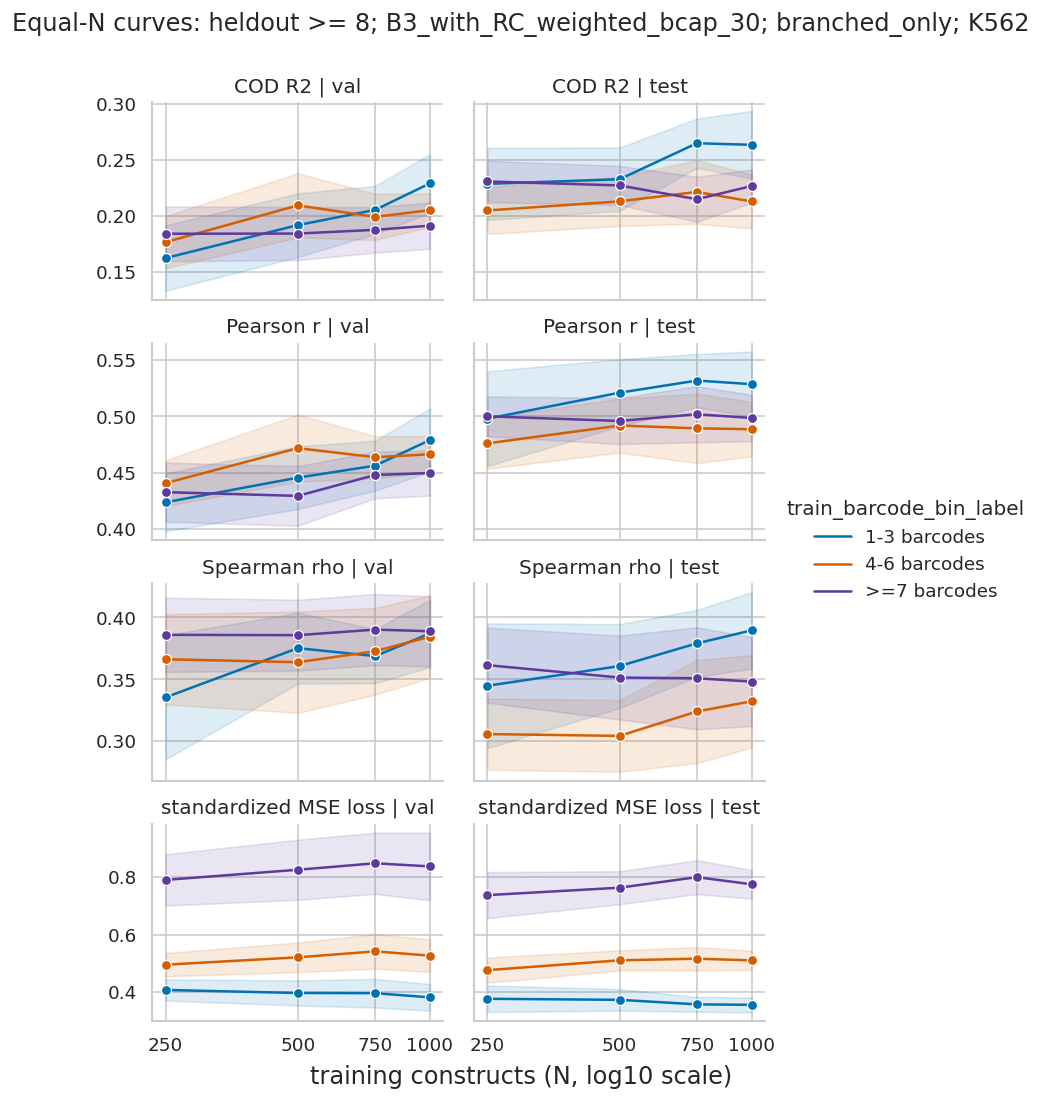

In [33]:
# Edit these knobs before re-running the cell.
plot_equal_n_learning_curves(
    perf_long,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_30',
    unfreeze_scope='branched_only',
    log_x=True,
)
plt.show()

## Per-Epoch Validation/Test Dynamics

The history CSV logs train, validation, and test evaluation metrics at every epoch. The helpers below reshape those histories into the same long metric format as the final learning-curve table, then plot trajectories for one fixed modeling condition.

The default `fraction_label='1.00'` shows the full training-fraction runs, while `heldout_min`, `setting`, `unfreeze_scope`, and `init_head` keep the comparison apples-to-apples. The shaded band is the standard error of the mean across matched replicate runs available at that epoch, not a separate barcode-count subgroup; because early stopping can remove runs at later epochs, late-epoch bands may summarize fewer runs.

For train loss, the long table uses `train_eval_loss_standardized` by default. That is the model evaluated on the original training constructs, making it more comparable to validation and test than the minibatch training-loss stream.


In [34]:
def make_epoch_metric_long(
    frame,
    metric_roots=None,
    split_values=SPLIT_ORDER,
    prefer_train_eval_loss=True,
):
    metric_roots = metric_roots or list(METRIC_SPECS)
    split_values = tuple(split_values)
    rows = []
    id_cols = [
        'run_id', 'epoch', 'seed', 'heldout_min_barcodes', 'split_strategy',
        'split_seed_effective', 'val_seed_effective', 'test_seed_effective',
        'train_barcode_bin', 'train_barcode_bin_label', 'train_sampling_mode',
        'setting', 'init_head', 'unfreeze_scope', 'train_size', 'train_fraction',
        'target_scaler_mean', 'target_scaler_std', 'trainable_params',
        'total_params', 'source_seed_dir',
    ]
    id_cols = [c for c in id_cols if c in frame.columns]
    for metric_root in metric_roots:
        spec = METRIC_SPECS[metric_root]
        for split in split_values:
            col = spec['cols'].get(split)
            if (
                split == 'train'
                and metric_root == 'loss'
                and prefer_train_eval_loss
                and 'train_eval_loss_standardized' in frame.columns
            ):
                col = 'train_eval_loss_standardized'
            if col not in frame.columns:
                continue
            part = frame[id_cols].copy()
            part['split'] = split
            part['metric_root'] = metric_root
            part['metric_label'] = spec['label']
            part['higher_is_better'] = spec['higher_is_better']
            part['source_column'] = col
            part['value'] = frame[col].to_numpy()
            rows.append(part)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    out['train_fraction_label'] = out['train_fraction'].map(
        lambda x: f'{float(x):.2f}' if pd.notna(x) else np.nan
    )
    out['train_barcode_bin_label'] = pd.Categorical(
        out['train_barcode_bin_label'], categories=BIN_LABEL_ORDER, ordered=True
    )
    return out


epoch_long = make_epoch_metric_long(histories)
print(epoch_long.shape)
display(epoch_long.head())


(317736, 28)


,run_id,epoch,seed,heldout_min_barcodes,split_strategy,split_seed_effective,val_seed_effective,test_seed_effective,train_barcode_bin,train_barcode_bin_label,train_sampling_mode,setting,init_head,unfreeze_scope,train_size,train_fraction,target_scaler_mean,target_scaler_std,trainable_params,total_params,source_seed_dir,split,metric_root,metric_label,higher_is_better,source_column,value,train_fraction_label
0,20260503T234431Z_aa92ec7d,0,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,branched_only,250,0.25,-0.544658,0.407363,179761,3747661,seed_23,train,cod_r2,COD R2,True,train_r2_cod,-0.486996,0.25
1,20260503T234431Z_aa92ec7d,1,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,branched_only,250,0.25,-0.544658,0.407363,179761,3747661,seed_23,train,cod_r2,COD R2,True,train_r2_cod,-0.283438,0.25
2,20260503T234431Z_aa92ec7d,2,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,branched_only,250,0.25,-0.544658,0.407363,179761,3747661,seed_23,train,cod_r2,COD R2,True,train_r2_cod,-0.145324,0.25
3,20260503T234431Z_aa92ec7d,3,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,branched_only,250,0.25,-0.544658,0.407363,179761,3747661,seed_23,train,cod_r2,COD R2,True,train_r2_cod,-0.057256,0.25
4,20260503T234431Z_aa92ec7d,4,23,4,random_hq_val_test_per_seed,723257,723257,723257,bc_1_3,1-3 barcodes,random,B2_with_RC,K562,branched_only,250,0.25,-0.544658,0.407363,179761,3747661,seed_23,train,cod_r2,COD R2,True,train_r2_cod,-0.002140,0.25


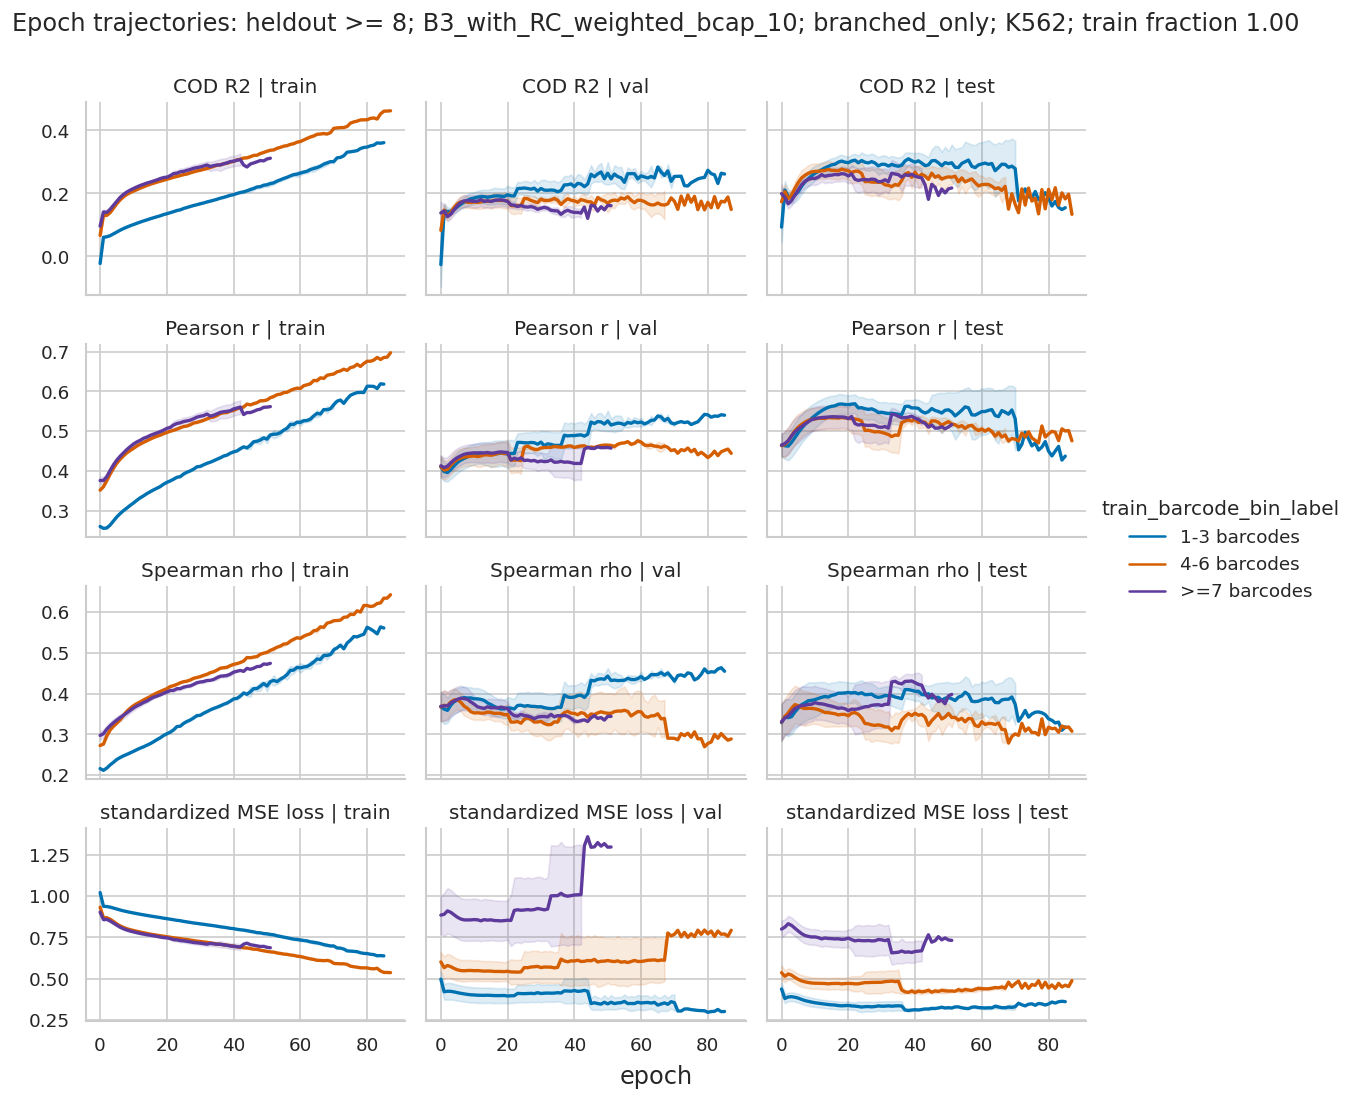

In [35]:
def plot_epoch_trajectories(
    epoch_long,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    init_head='K562',
    fraction_label='1.00',
    train_size=None,
    metrics=('cod_r2', 'pearson', 'spearman', 'loss'),
    split_values=('train', 'val', 'test'),
    errorbar='se',
    error_band_alpha=ERROR_BAND_ALPHA,
    epoch_min=None,
    epoch_max=None,
):
    plot_df = epoch_long.query(
        'heldout_min_barcodes == @heldout_min and setting == @setting and '
        'unfreeze_scope == @unfreeze_scope and init_head == @init_head'
    ).copy()
    if fraction_label is not None:
        plot_df = plot_df[plot_df['train_fraction_label'] == str(fraction_label)]
    if train_size is not None:
        plot_df = plot_df[plot_df['train_size'] == train_size]
    plot_df = plot_df[
        plot_df['metric_root'].isin(metrics) & plot_df['split'].isin(split_values)
    ].copy()
    if epoch_min is not None:
        plot_df = plot_df[plot_df['epoch'] >= epoch_min]
    if epoch_max is not None:
        plot_df = plot_df[plot_df['epoch'] <= epoch_max]
    plot_df = plot_df[np.isfinite(plot_df['value'])]
    if plot_df.empty:
        print(
            'No epoch data after filtering: '
            f'heldout >= {heldout_min}, setting={setting}, '
            f'scope={unfreeze_scope}, head={init_head}, '
            f'fraction={fraction_label}, train_size={train_size}'
        )
        return None

    metric_order = [METRIC_SPECS[m]['label'] for m in metrics if m in METRIC_SPECS]
    g = sns.relplot(
        data=plot_df,
        x='epoch',
        y='value',
        hue='train_barcode_bin_label',
        hue_order=BIN_LABEL_ORDER,
        palette=BIN_PALETTE,
        col='split',
        col_order=list(split_values),
        row='metric_label',
        row_order=metric_order,
        kind='line',
        estimator='mean',
        errorbar=errorbar,
        err_kws={'alpha': error_band_alpha},
        linewidth=2,
        facet_kws={'sharey': 'row', 'sharex': True},
        height=2.35,
        aspect=1.35,
    )
    g.set_axis_labels('', '')
    g.set_titles(row_template='{row_name}', col_template='{col_name}')
    g.fig.supxlabel('epoch', y=0.025)
    g.fig.subplots_adjust(top=0.90, bottom=0.085)
    title_bits = [
        f'heldout >= {heldout_min}',
        setting,
        unfreeze_scope,
        init_head,
        f'train fraction {fraction_label}',
    ]
    if train_size is not None:
        title_bits.append(f'N = {train_size}')
    g.fig.suptitle('Epoch trajectories: ' + '; '.join(title_bits))
    return g


# Full-training-fraction example. Change these knobs to compare other settings.
plot_epoch_trajectories(
    epoch_long,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    fraction_label='1.00',
)
plt.show()


In [36]:
# Sanity check: this should include train, val, and test rows for every metric.
epoch_split_check = (
    epoch_long.groupby(['metric_label', 'split'], observed=True)['value']
    .count()
    .unstack('split')
    .reindex(columns=SPLIT_ORDER)
)
display(epoch_split_check)


split,train,val,test
metric_label,,,
COD R2,26478,26478,26478
Pearson r,26478,26478,26478
Spearman rho,26478,26478,26478
standardized MSE loss,26478,26478,26478


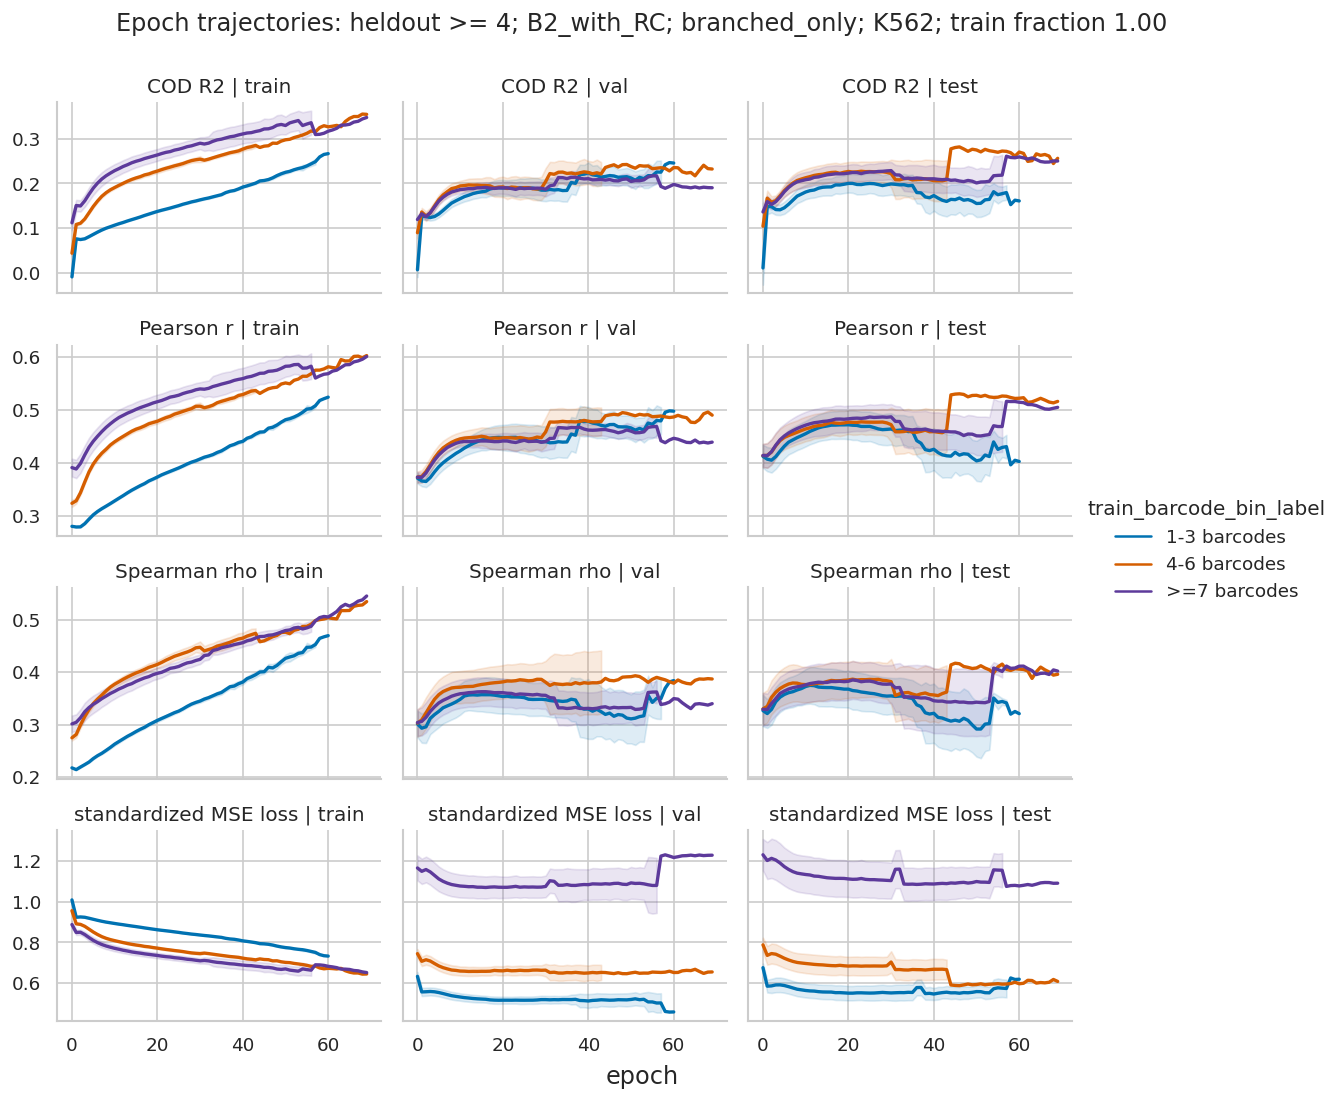

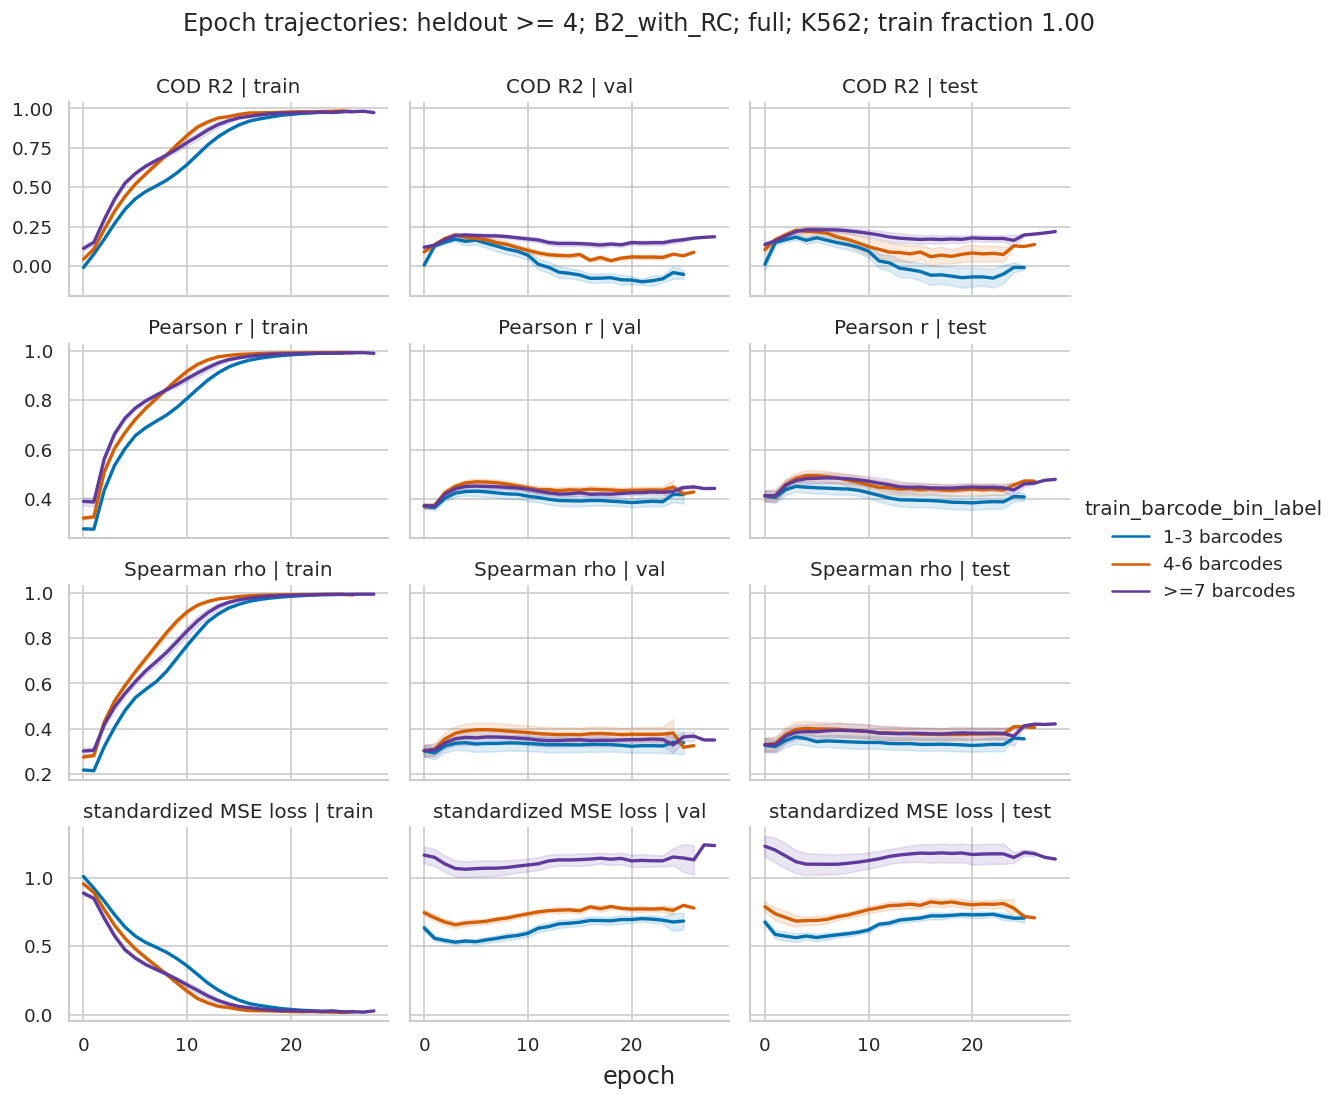

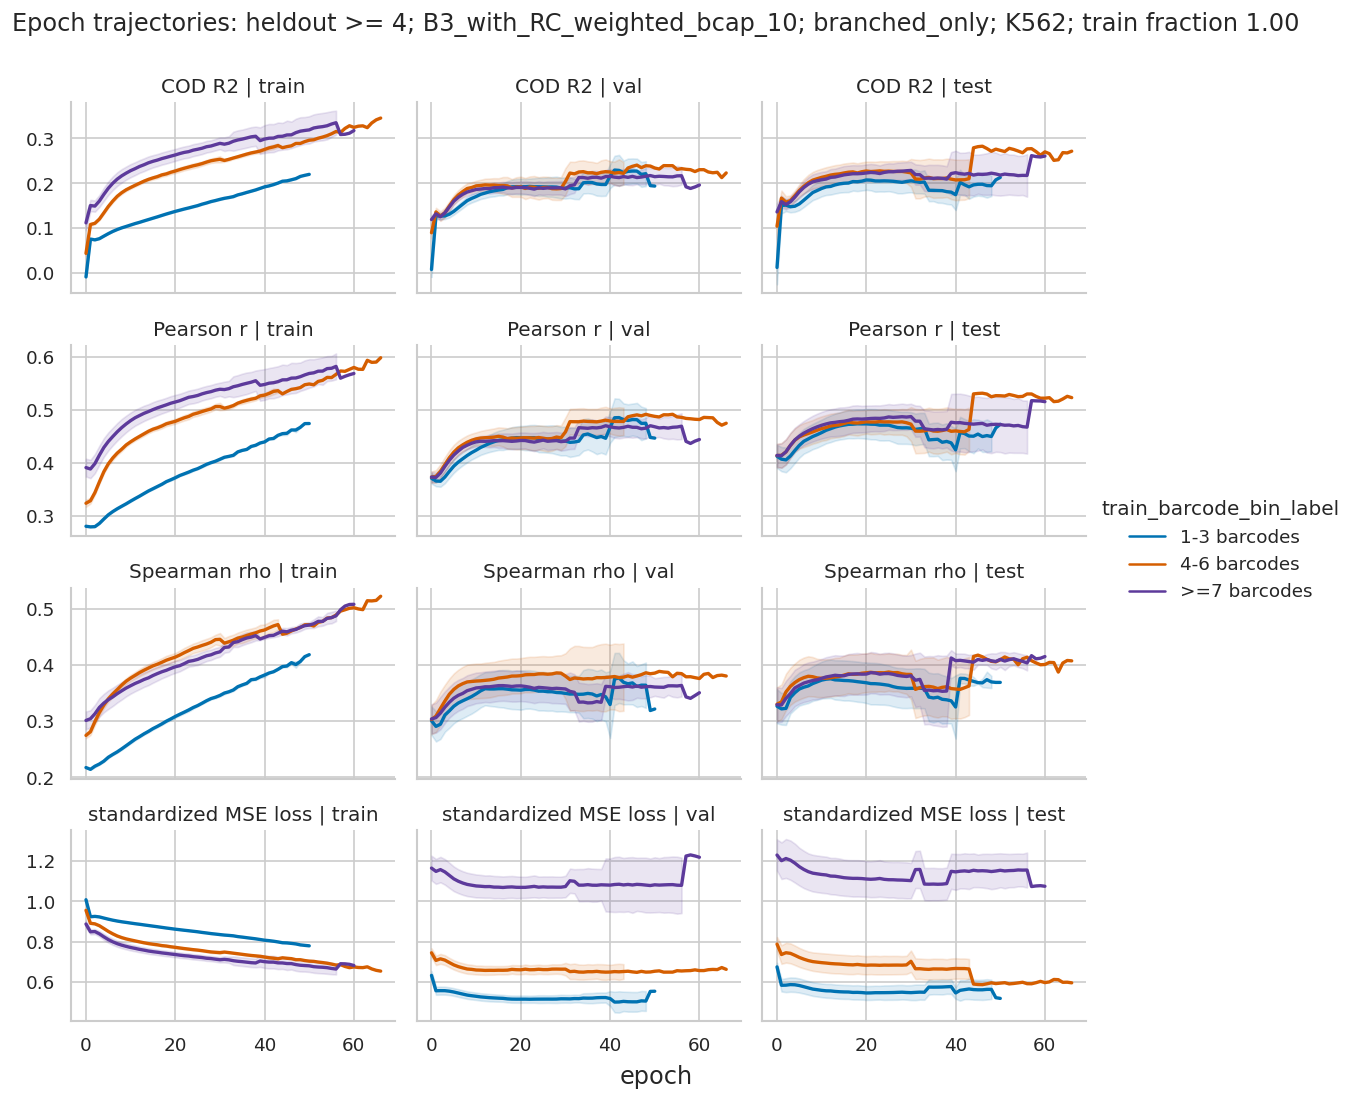

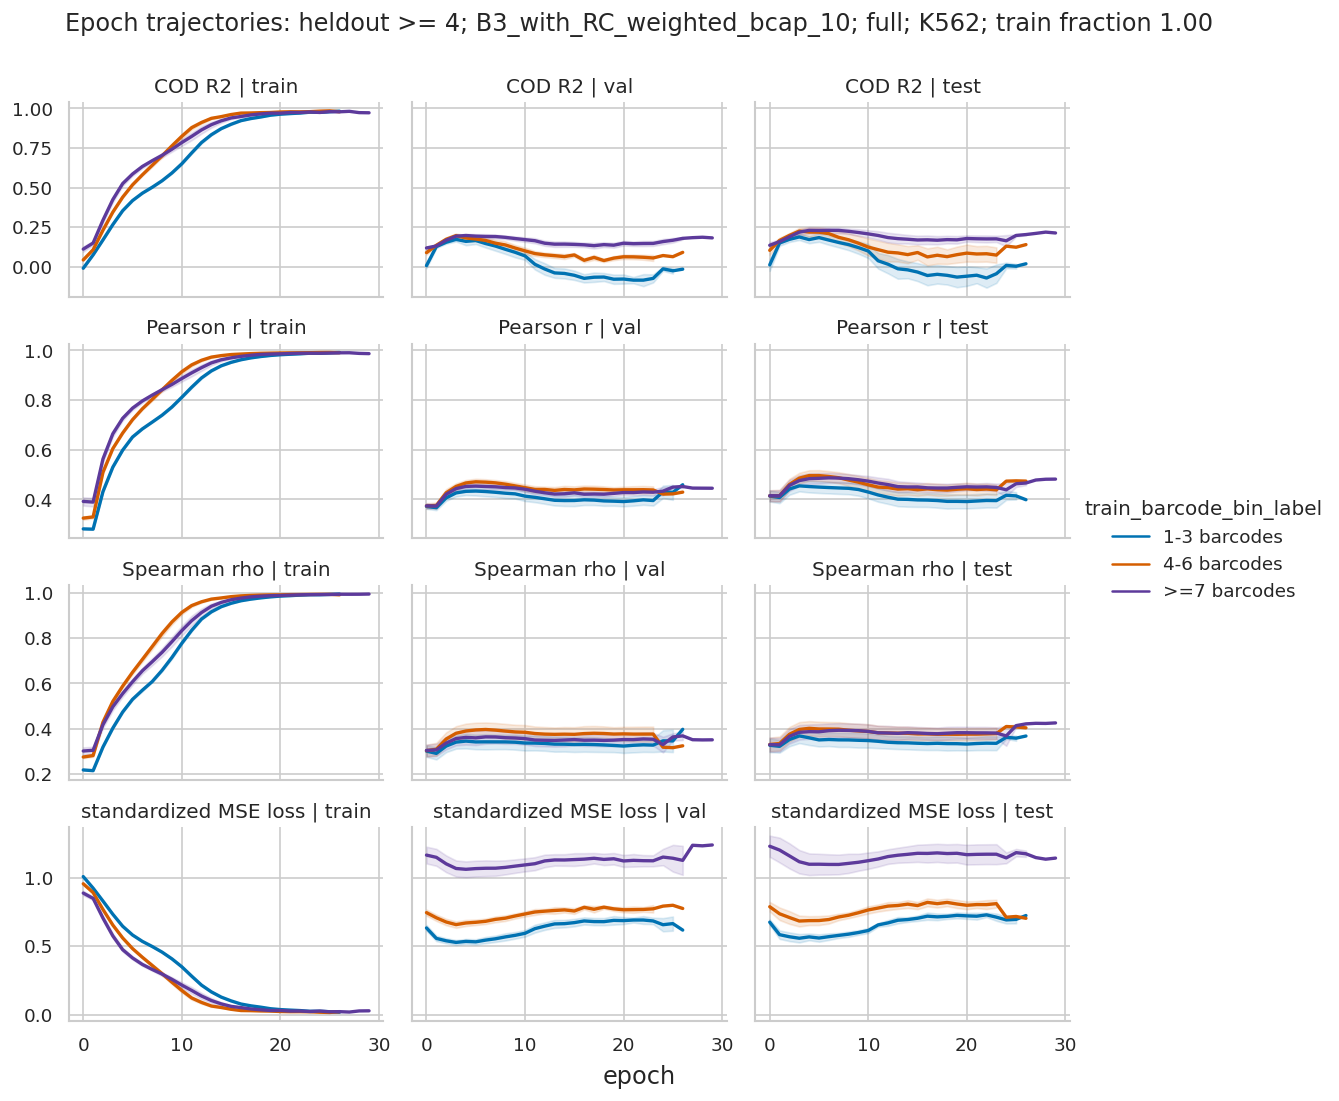

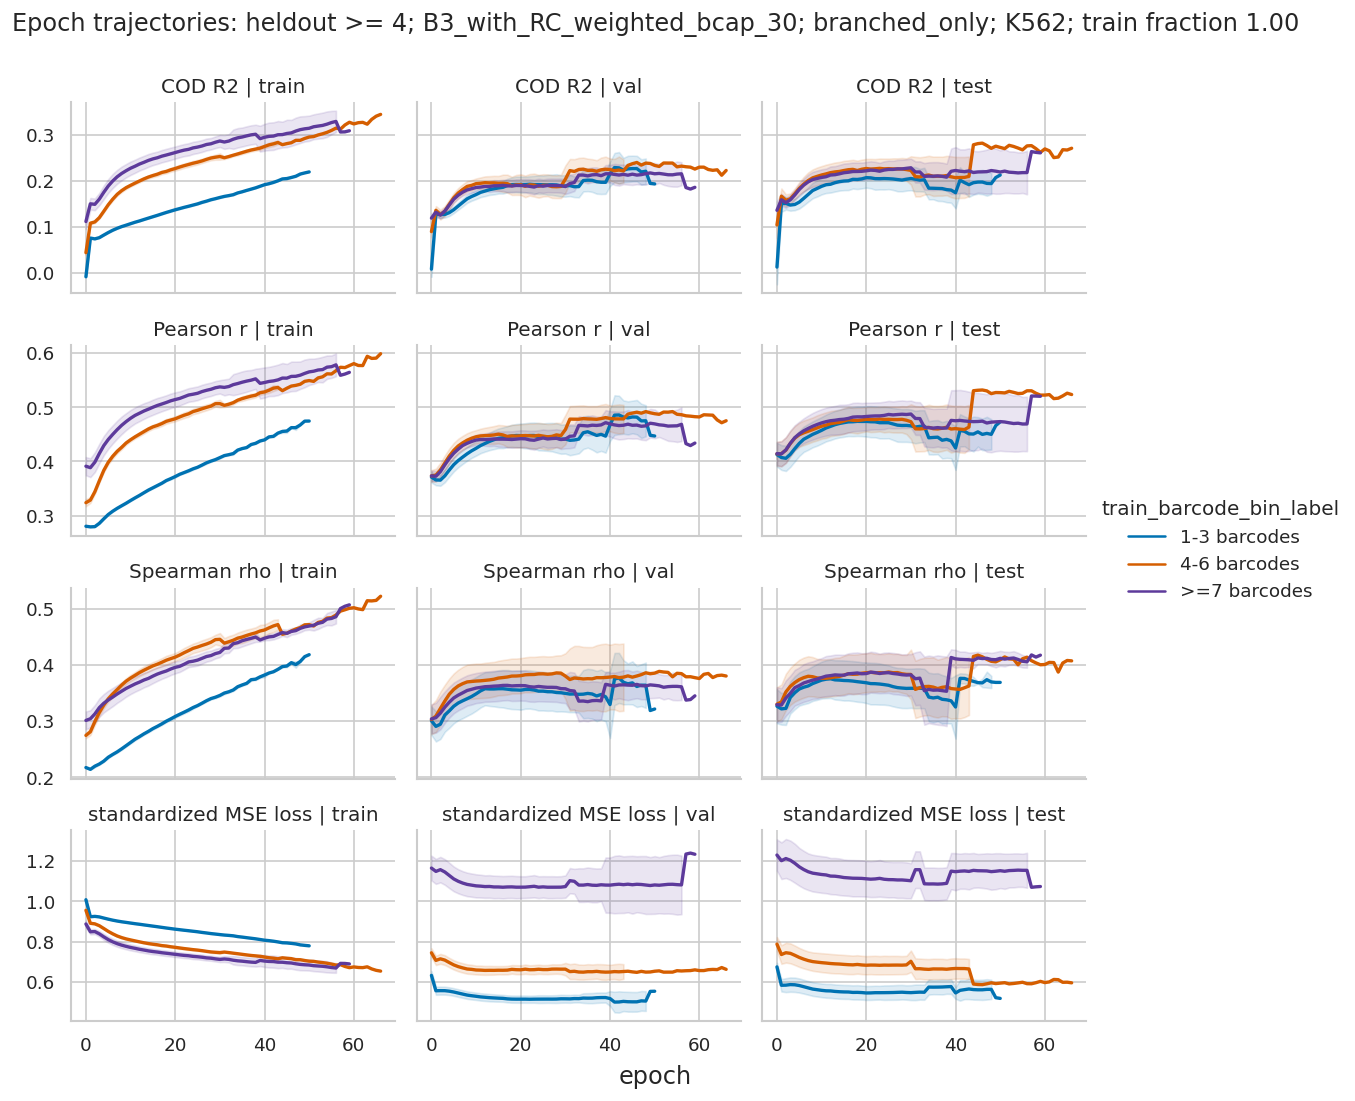

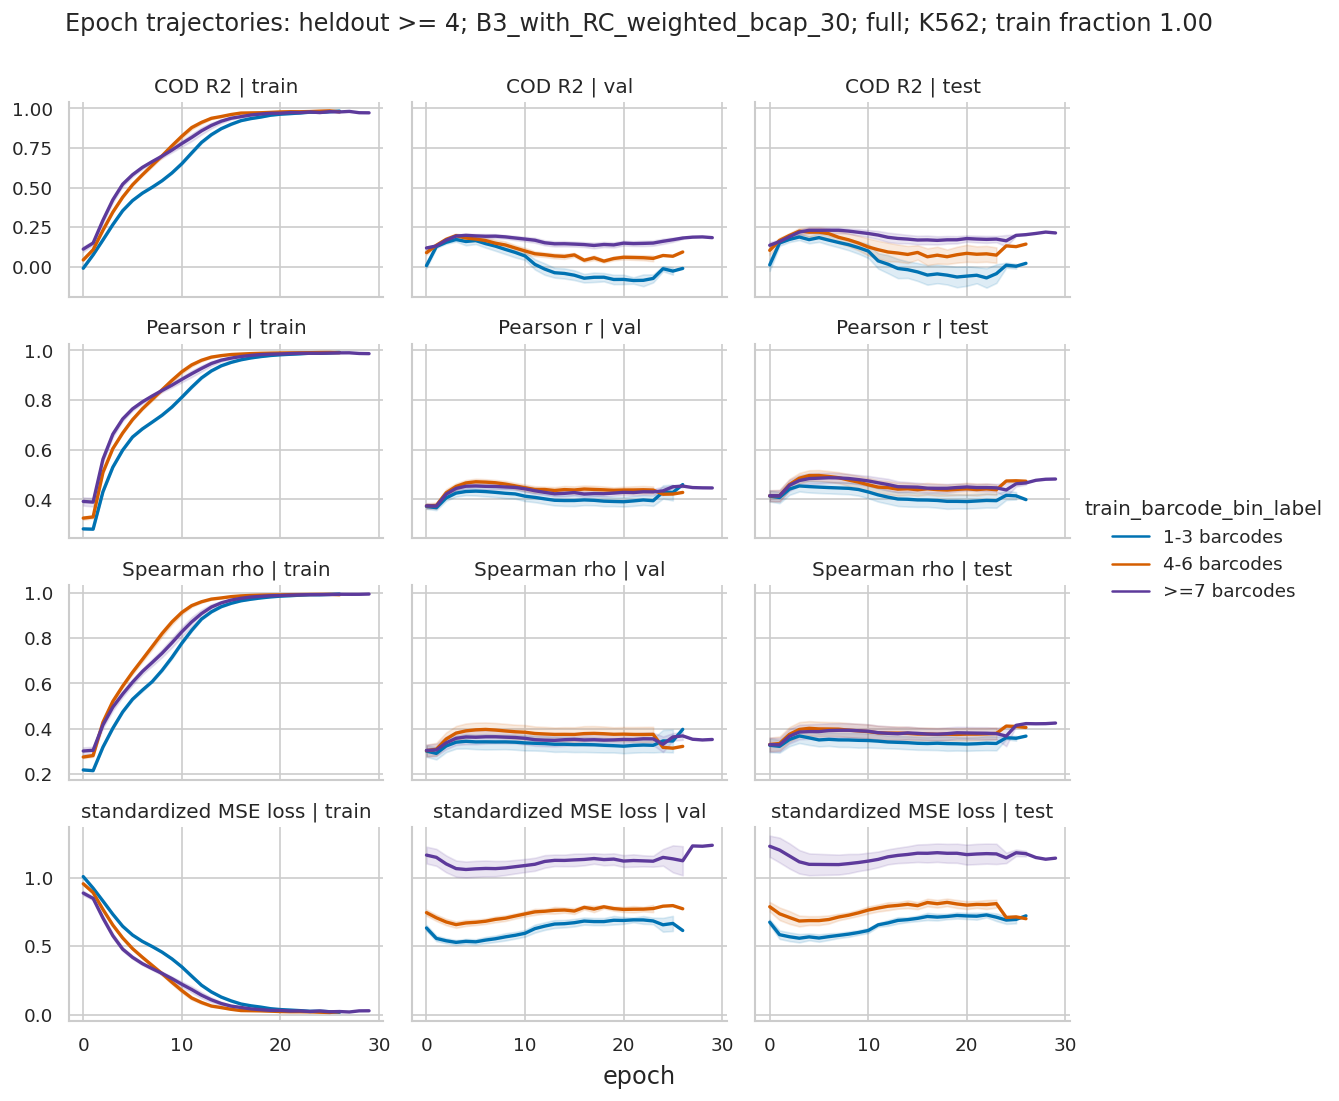

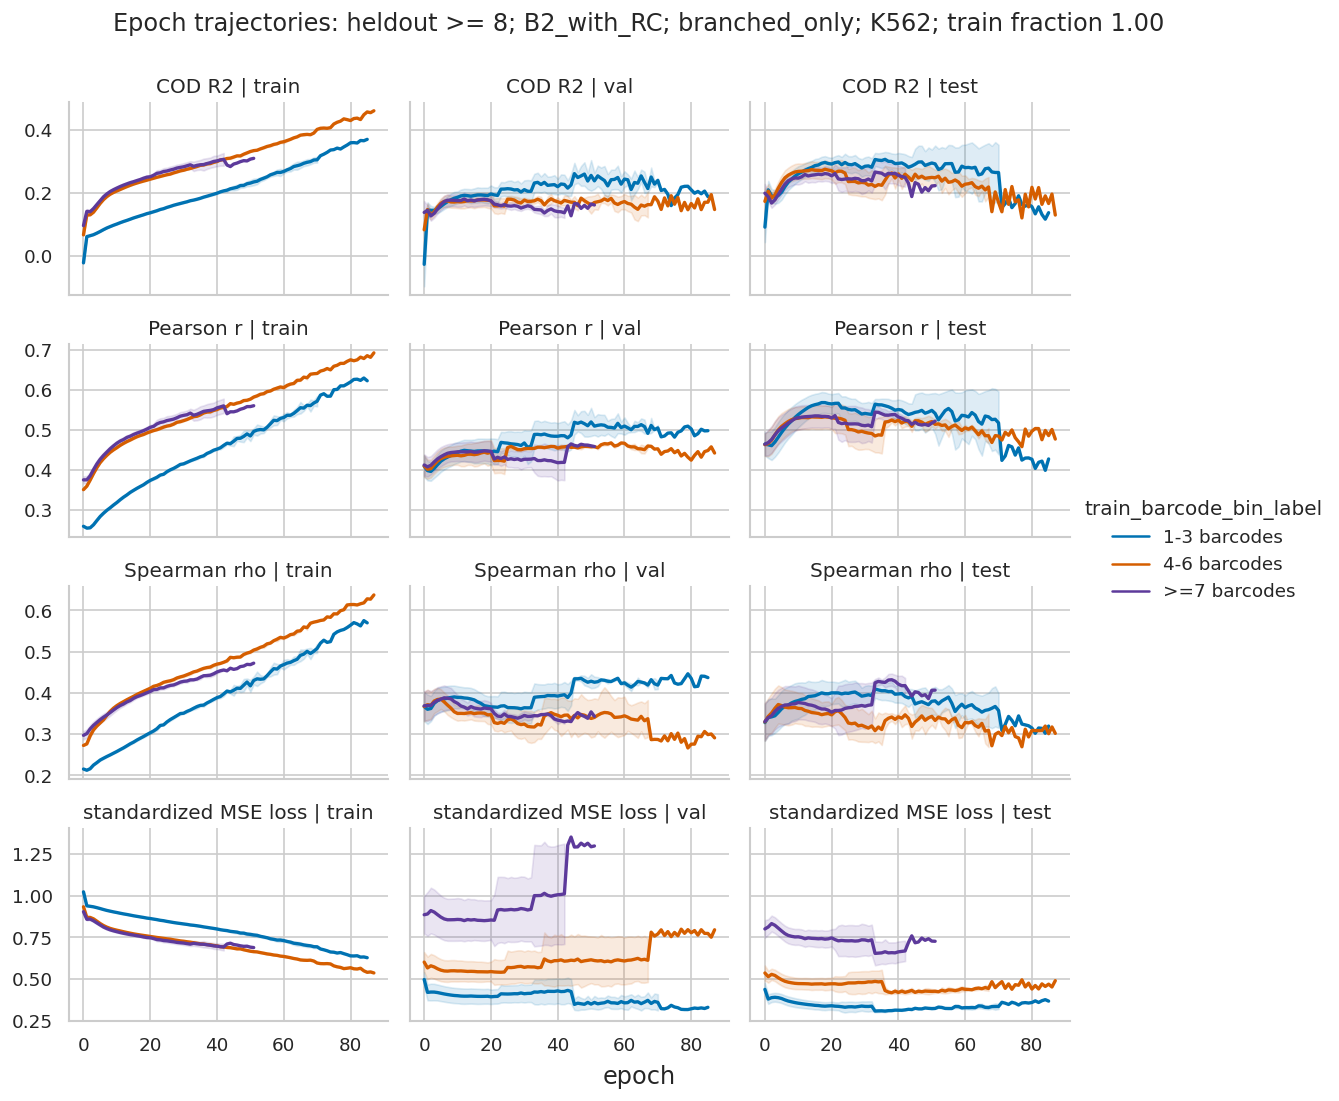

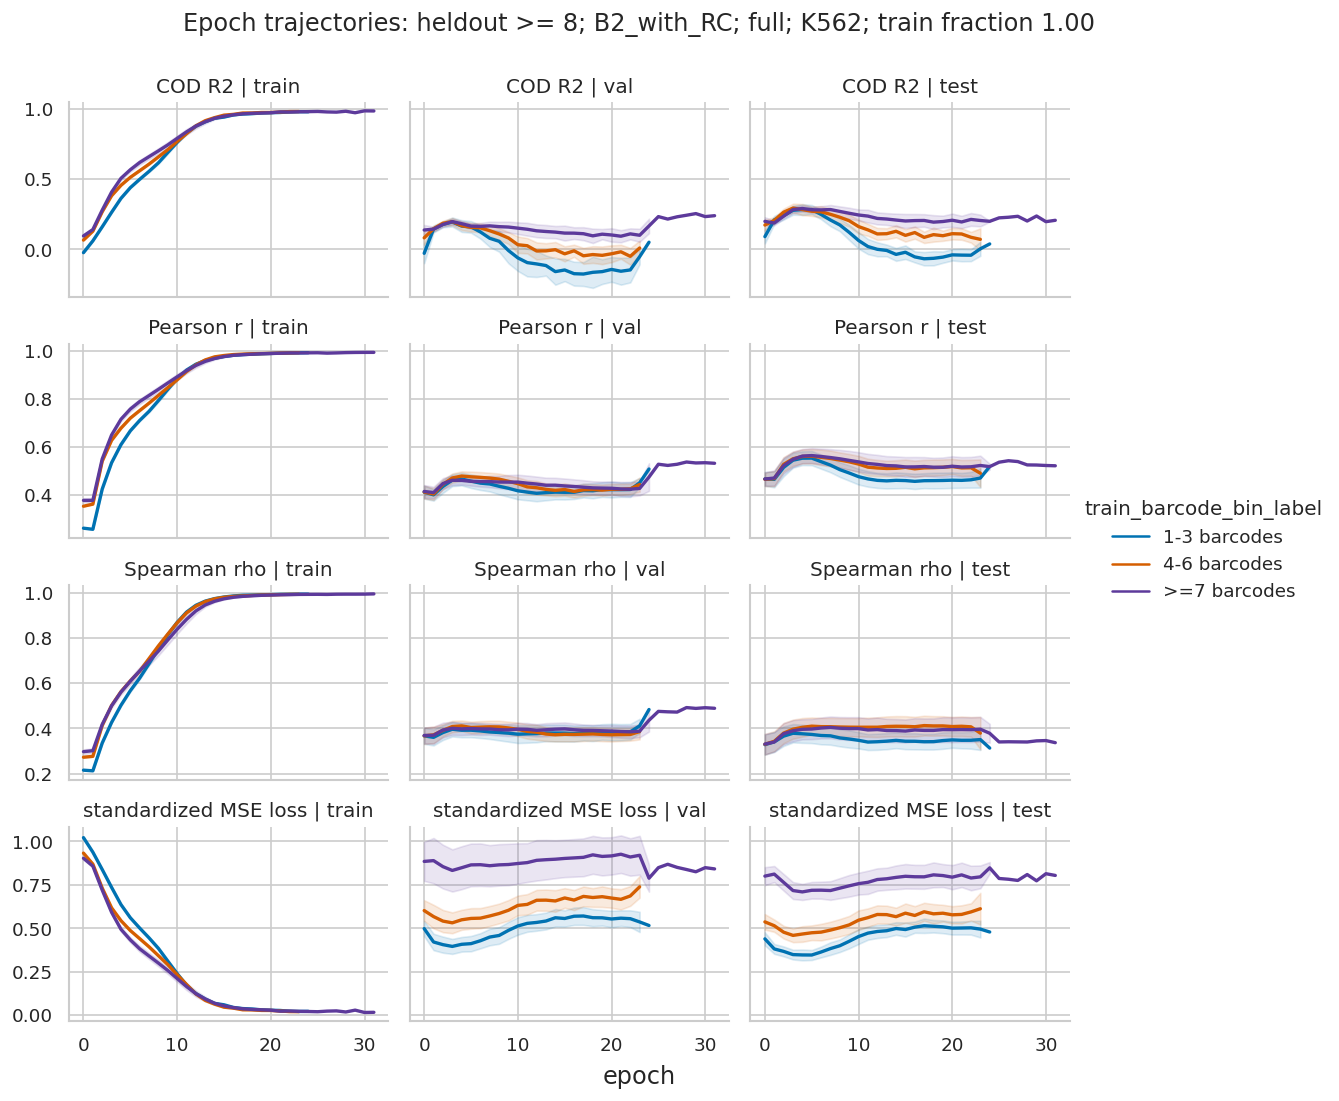

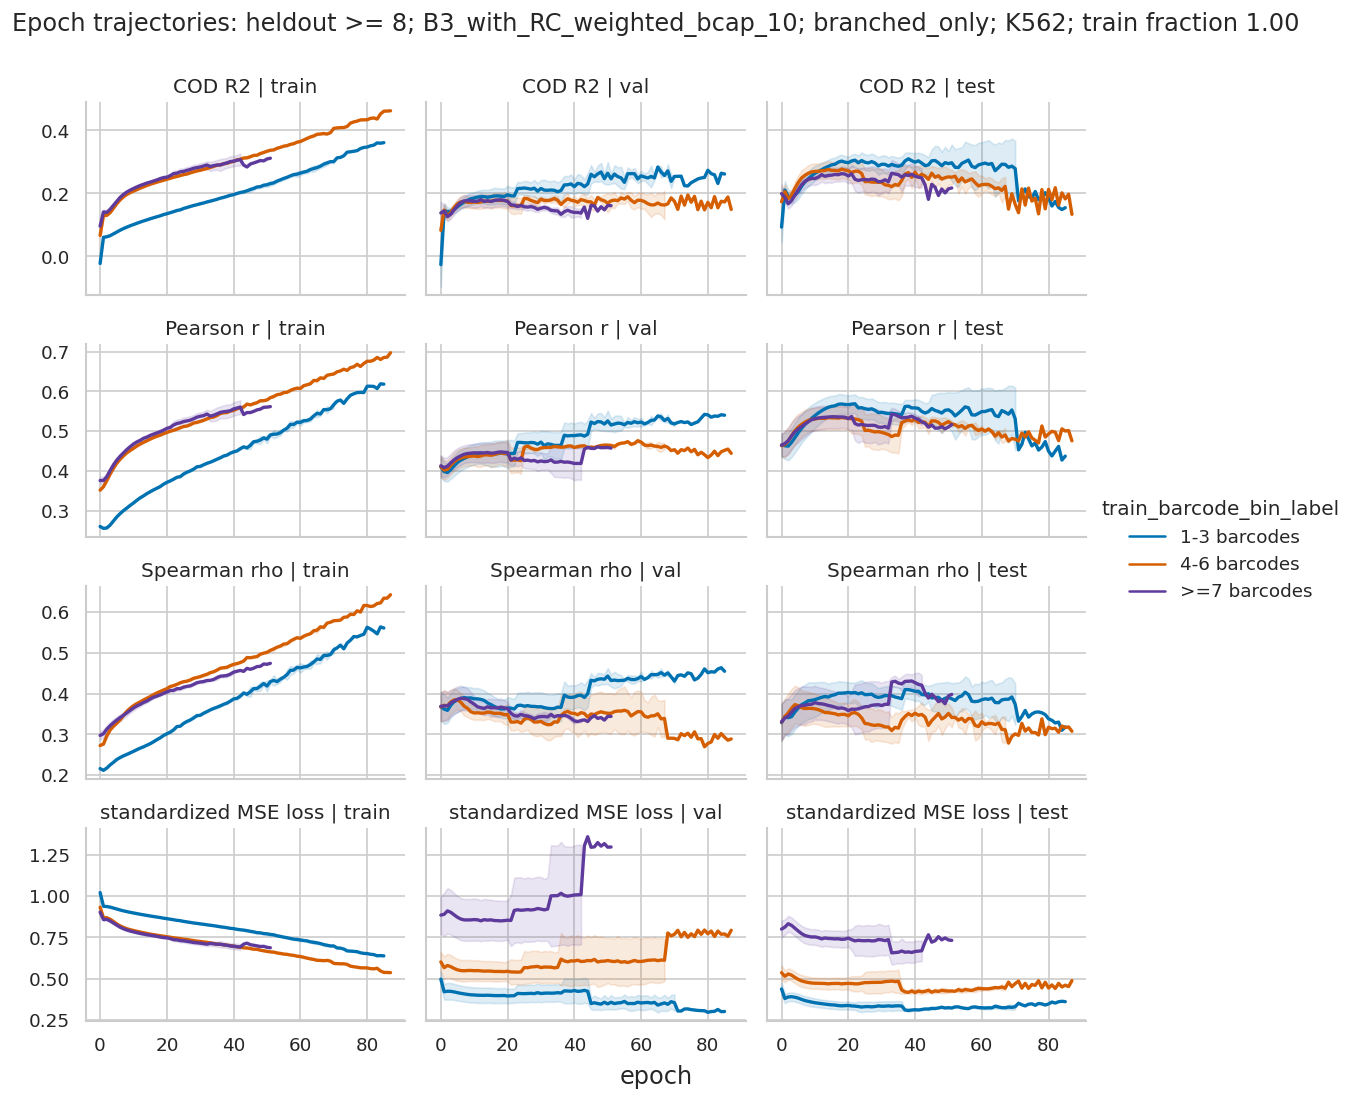

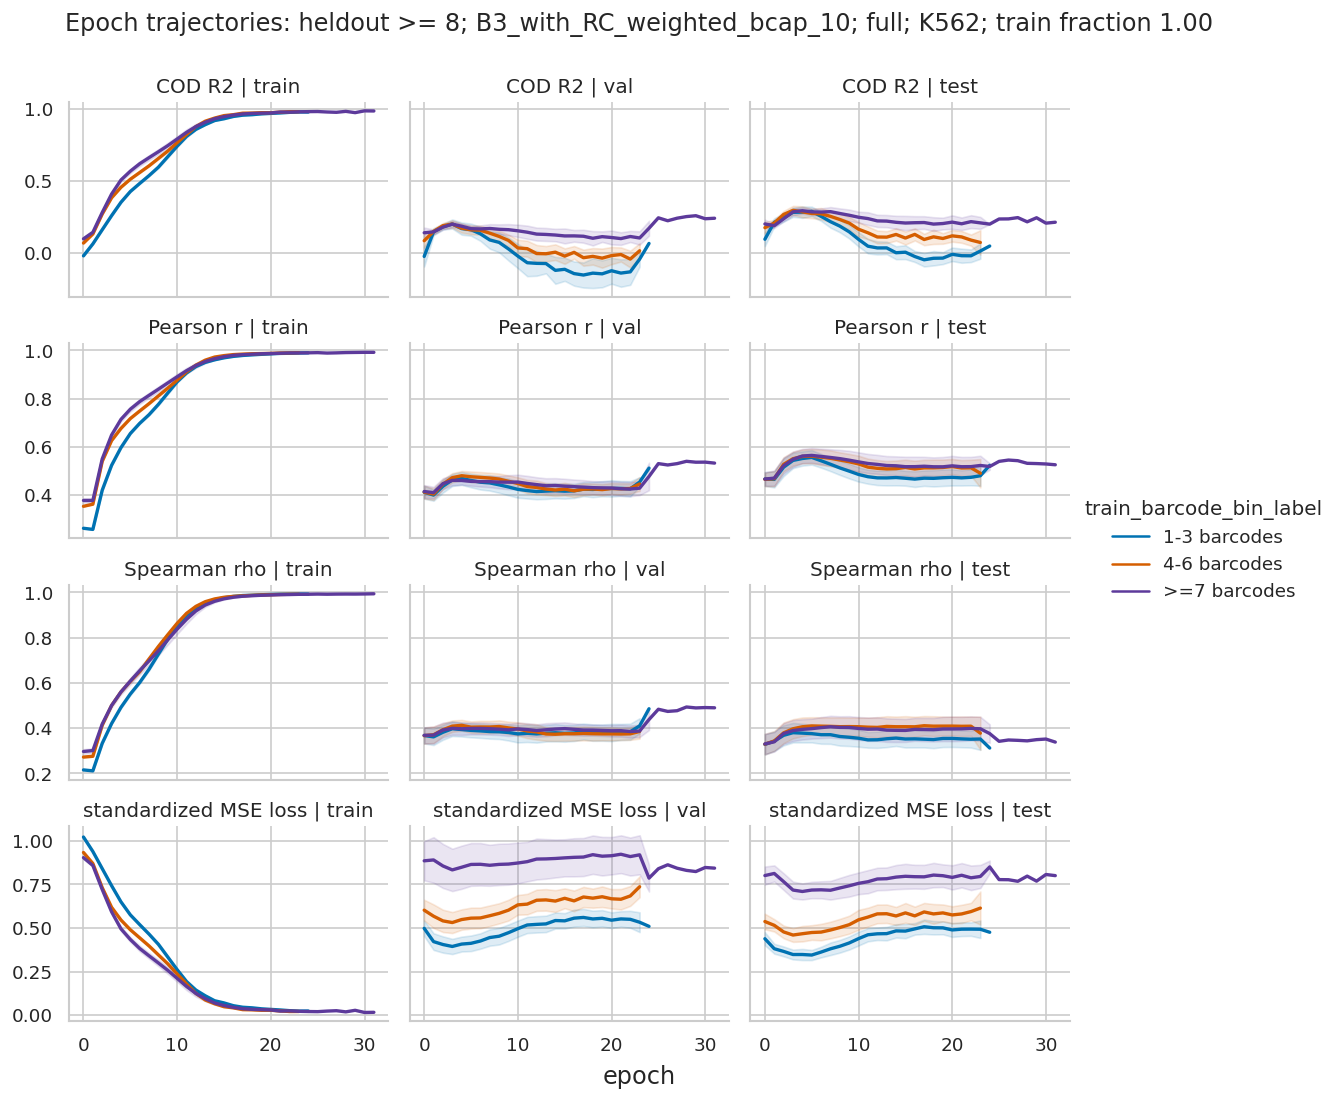

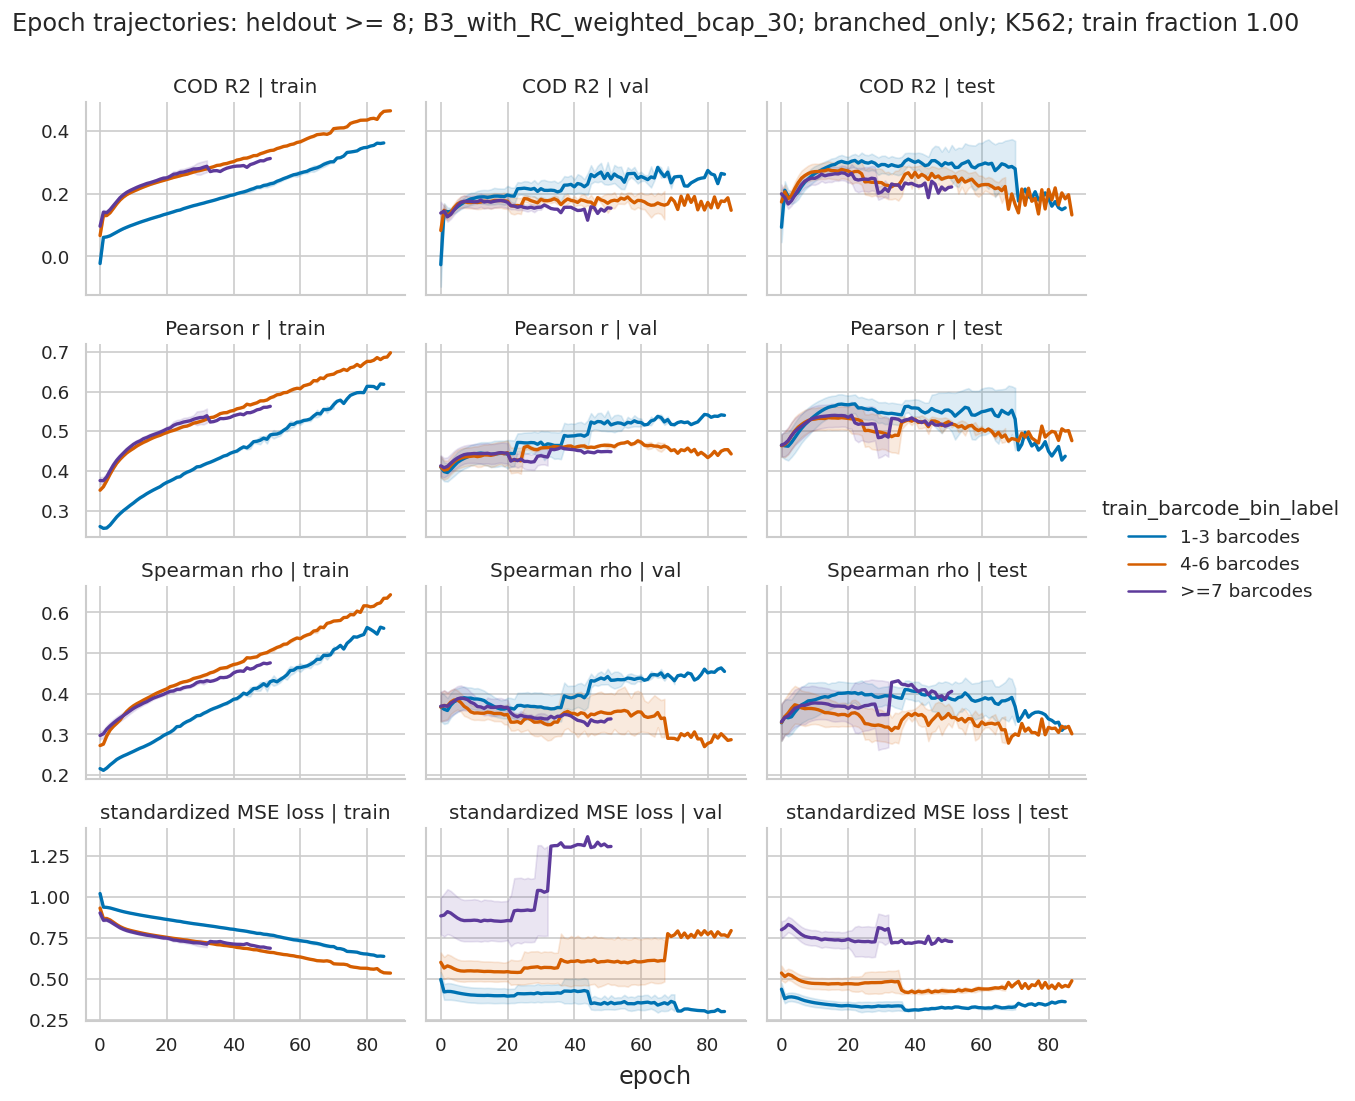

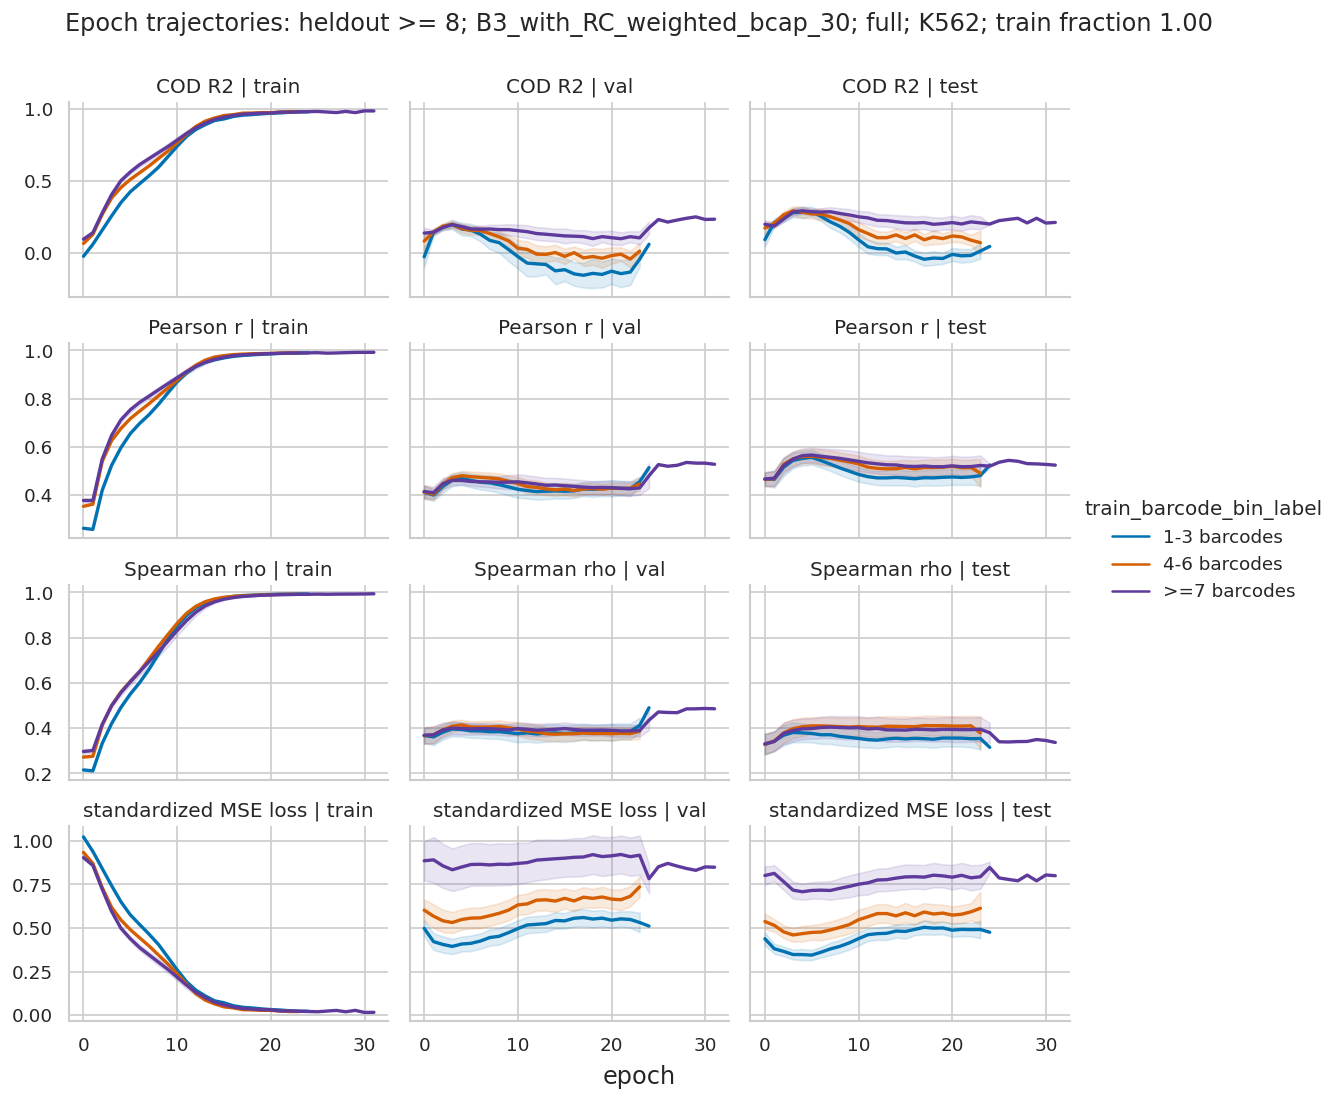

In [55]:
# Optional sweep over all heldout thresholds, settings, and unfreeze scopes at full train fraction.
# This makes 12 figures for the current run, so keep it as an explicit opt-in cell.
for heldout_min in sorted(epoch_long['heldout_min_barcodes'].dropna().unique()):
    for setting in SETTING_ORDER:
        for scope in UNFREEZE_ORDER:
            g = plot_epoch_trajectories(
                epoch_long,
                heldout_min=int(heldout_min),
                setting=setting,
                unfreeze_scope=scope,
                fraction_label='1.00',
            )
            if g is not None:
                plt.show()


## Unfreeze-Scope Global Comparison

These summaries compare `branched_only` against `full` while keeping the other knobs fixed. The paired unit is a matched seed, heldout threshold, setting, head, barcode bin, train size, train fraction, split, and metric.

`mean_benefit_delta > 0` means `branched_only` is better than `full`; for COD R2/Pearson/Spearman this is `branched_only - full`, and for standardized loss it is `full - branched_only`. This is a hyperparameter diagnostic, not a replacement for the downstream barcode-bin paired deltas.


In [38]:
def summarize_unfreeze_scope_effect(
    perf_long,
    heldout_min=None,
    setting=None,
    init_head='K562',
    fraction_label='1.00',
    candidate_scope='branched_only',
    reference_scope='full',
    metrics=('cod_r2', 'pearson', 'spearman', 'loss'),
    split_values=('train', 'val', 'test'),
    group_barcode_bins=False,
):
    df = perf_long.copy()
    df['train_fraction_label'] = df['train_fraction'].map(
        lambda x: f'{float(x):.2f}' if pd.notna(x) else np.nan
    )
    if heldout_min is not None:
        df = df[df['heldout_min_barcodes'] == heldout_min]
    if setting is not None:
        df = df[df['setting'] == setting]
    if init_head is not None:
        df = df[df['init_head'] == init_head]
    if fraction_label is not None:
        df = df[df['train_fraction_label'] == str(fraction_label)]
    df = df[df['metric_root'].isin(metrics) & df['split'].isin(split_values)].copy()

    pair_keys = [
        'seed', 'heldout_min_barcodes', 'setting', 'init_head', 'train_size',
        'train_fraction', 'train_barcode_bin', 'train_barcode_bin_label',
        'split', 'metric_root', 'metric_label', 'higher_is_better',
    ]
    pair_keys = [c for c in pair_keys if c in df.columns]
    wide = (
        df.pivot_table(
            index=pair_keys,
            columns='unfreeze_scope',
            values='value',
            aggfunc='mean',
            observed=True,
        )
        .reset_index()
    )
    if candidate_scope not in wide.columns or reference_scope not in wide.columns:
        return pd.DataFrame()
    wide = wide.dropna(subset=[candidate_scope, reference_scope]).copy()
    wide['raw_delta'] = wide[candidate_scope] - wide[reference_scope]
    wide['benefit_delta'] = np.where(
        wide['higher_is_better'], wide['raw_delta'], -wide['raw_delta']
    )

    group_cols = [
        'heldout_min_barcodes', 'setting', 'init_head', 'split',
        'metric_root', 'metric_label', 'higher_is_better',
    ]
    if group_barcode_bins:
        group_cols += ['train_barcode_bin', 'train_barcode_bin_label']
    summary = (
        wide.groupby(group_cols, observed=True, dropna=False)
        .agg(
            n=('benefit_delta', 'count'),
            mean_candidate_value=(candidate_scope, 'mean'),
            mean_reference_value=(reference_scope, 'mean'),
            mean_raw_delta=('raw_delta', 'mean'),
            mean_benefit_delta=('benefit_delta', 'mean'),
            sd_benefit_delta=('benefit_delta', 'std'),
        )
        .reset_index()
    )
    summary['se_benefit_delta'] = summary['sd_benefit_delta'] / np.sqrt(summary['n'])
    summary['ci95_low'] = summary['mean_benefit_delta'] - 1.96 * summary['se_benefit_delta']
    summary['ci95_high'] = summary['mean_benefit_delta'] + 1.96 * summary['se_benefit_delta']
    summary['candidate_scope'] = candidate_scope
    summary['reference_scope'] = reference_scope
    summary['split'] = pd.Categorical(
        summary['split'], categories=list(split_values), ordered=True
    )
    sort_cols = ['heldout_min_barcodes', 'setting', 'split', 'metric_root']
    if group_barcode_bins:
        sort_cols.append('train_barcode_bin_label')
    return summary.sort_values(sort_cols).reset_index(drop=True)


def summarize_unfreeze_epoch_length(
    histories,
    heldout_min=None,
    setting=None,
    init_head='K562',
    fraction_label='1.00',
    group_barcode_bins=False,
):
    df = histories.copy()
    df['train_fraction_label'] = df['train_fraction'].map(
        lambda x: f'{float(x):.2f}' if pd.notna(x) else np.nan
    )
    if heldout_min is not None:
        df = df[df['heldout_min_barcodes'] == heldout_min]
    if setting is not None:
        df = df[df['setting'] == setting]
    if init_head is not None:
        df = df[df['init_head'] == init_head]
    if fraction_label is not None:
        df = df[df['train_fraction_label'] == str(fraction_label)]

    run_keys = [
        'seed', 'heldout_min_barcodes', 'setting', 'init_head', 'unfreeze_scope',
        'train_barcode_bin', 'train_barcode_bin_label', 'train_size', 'train_fraction',
    ]
    run_keys = [c for c in run_keys if c in df.columns]
    run_epochs = (
        df.groupby(run_keys, observed=True, dropna=False)
        .agg(last_epoch=('epoch', 'max'), n_logged_epochs=('epoch', 'nunique'))
        .reset_index()
    )
    group_cols = ['heldout_min_barcodes', 'setting', 'init_head', 'unfreeze_scope']
    if group_barcode_bins:
        group_cols += ['train_barcode_bin', 'train_barcode_bin_label']
    summary = (
        run_epochs.groupby(group_cols, observed=True, dropna=False)
        .agg(
            n_runs=('last_epoch', 'count'),
            mean_last_epoch=('last_epoch', 'mean'),
            sd_last_epoch=('last_epoch', 'std'),
            mean_logged_epochs=('n_logged_epochs', 'mean'),
        )
        .reset_index()
        .sort_values(['heldout_min_barcodes', 'setting', 'unfreeze_scope'])
    )
    summary['se_last_epoch'] = summary['sd_last_epoch'] / np.sqrt(summary['n_runs'])
    return summary.reset_index(drop=True)


scope_effect_global = summarize_unfreeze_scope_effect(
    perf_long,
    heldout_min=None,
    setting=None,
    fraction_label='1.00',
    group_barcode_bins=False,
)
display(scope_effect_global[[
    'heldout_min_barcodes', 'setting', 'split', 'metric_label', 'n',
    'mean_candidate_value', 'mean_reference_value',
    'mean_benefit_delta', 'ci95_low', 'ci95_high',
    'candidate_scope', 'reference_scope',
]])

scope_epoch_length = summarize_unfreeze_epoch_length(
    histories,
    heldout_min=None,
    setting=None,
    fraction_label='1.00',
    group_barcode_bins=False,
)
display(scope_epoch_length)


,heldout_min_barcodes,setting,split,metric_label,n,mean_candidate_value,mean_reference_value,mean_benefit_delta,ci95_low,ci95_high,candidate_scope,reference_scope
0,4,B2_with_RC,train,COD R2,15,0.219787,0.429726,-0.209939,-0.252383,-0.167495,branched_only,full
1,4,B2_with_RC,train,standardized MSE loss,15,0.779433,0.569704,-0.209729,-0.252131,-0.167328,branched_only,full
2,4,B2_with_RC,train,Pearson r,15,0.467640,0.658812,-0.191172,-0.213675,-0.168669,branched_only,full
3,4,B2_with_RC,train,Spearman rho,15,0.387284,0.539582,-0.152298,-0.181846,-0.122749,branched_only,full
4,4,B2_with_RC,val,COD R2,15,0.204474,0.194675,0.009798,-0.001572,0.021168,branched_only,full
5,4,B2_with_RC,val,standardized MSE loss,15,0.737161,0.743470,0.006309,-0.003508,0.016126,branched_only,full
6,4,B2_with_RC,val,Pearson r,15,0.455996,0.448966,0.007031,-0.003057,0.017119,branched_only,full
7,4,B2_with_RC,val,Spearman rho,15,0.370194,0.360280,0.009914,-0.001560,0.021387,branched_only,full
8,4,B2_with_RC,test,COD R2,15,0.215030,0.211467,0.003563,-0.011118,0.018244,branched_only,full
9,4,B2_with_RC,test,standardized MSE loss,15,0.782630,0.783605,0.000976,-0.011940,0.013891,branched_only,full


,heldout_min_barcodes,setting,init_head,unfreeze_scope,n_runs,mean_last_epoch,sd_last_epoch,mean_logged_epochs,se_last_epoch
0,4,B2_with_RC,K562,branched_only,15,46.400000,14.110786,47.400000,3.643389
1,4,B2_with_RC,K562,full,15,24.133333,1.552264,25.133333,0.400793
2,4,B3_with_RC_weighted_bcap_10,K562,branched_only,15,42.466667,11.531737,43.466667,2.977482
3,4,B3_with_RC_weighted_bcap_10,K562,full,15,24.200000,1.820518,25.200000,0.470056
4,4,B3_with_RC_weighted_bcap_30,K562,branched_only,15,42.400000,11.425535,43.400000,2.950061
5,4,B3_with_RC_weighted_bcap_30,K562,full,15,24.200000,1.820518,25.200000,0.470056
6,8,B2_with_RC,K562,branched_only,15,43.466667,23.479069,44.466667,6.062269
7,8,B2_with_RC,K562,full,15,23.466667,2.166850,24.466667,0.559478
8,8,B3_with_RC_weighted_bcap_10,K562,branched_only,15,43.733333,23.361955,44.733333,6.032031
9,8,B3_with_RC_weighted_bcap_10,K562,full,15,23.466667,2.166850,24.466667,0.559478


## Paired Deltas Within The Same Seed And Split

The reference here is `>=7 barcodes`. For each matched condition, we compute:

`raw_delta = candidate_metric - reference_metric`

Then we convert to `benefit_delta`, where positive always means the candidate bin is better than the reference:

- For Pearson, Spearman, and COD R2: `benefit_delta = raw_delta`.
- For loss: `benefit_delta = -raw_delta`, because lower loss is better.

This makes plots and non-inferiority checks easier to read.


In [39]:
# the keys that are kept in the paired delta computation
PAIR_KEYS = [
    'heldout_min_barcodes', 'seed', 'split_strategy', 'split_seed_effective',
    'val_seed_effective', 'test_seed_effective', 'setting', 'init_head',
    'unfreeze_scope', 'train_sampling_mode', 'train_size',
]


def compute_paired_deltas(frame, split='test', reference_bin='bc_ge7', metric_roots=None):
    metric_roots = metric_roots or list(METRIC_SPECS)
    records = []
    keys = [c for c in PAIR_KEYS if c in frame.columns]

    meta_cols = [
        'train_barcode_bin_label', 'train_pool_eligible_size', 'train_barcode_mean',
        'train_barcode_median', 'train_hq_fraction', 'target_scaler_mean', 'target_scaler_std',
    ]

    for metric_root in metric_roots:
        spec = METRIC_SPECS[metric_root]
        metric_col = spec['cols'][split]
        value_wide = frame.pivot_table(
            index=keys,
            columns='train_barcode_bin',
            values=metric_col,
            aggfunc='first',
        )
        if reference_bin not in value_wide.columns:
            continue

        for candidate_bin in BIN_ORDER:
            if candidate_bin == reference_bin or candidate_bin not in value_wide.columns:
                continue
            delta = value_wide[candidate_bin] - value_wide[reference_bin]
            part = delta.rename('raw_delta').reset_index()
            part = part.dropna(subset=['raw_delta'])
            part['candidate_bin'] = candidate_bin
            part['candidate_label'] = BIN_LABELS[candidate_bin]
            part['reference_bin'] = reference_bin
            part['reference_label'] = BIN_LABELS[reference_bin]
            part['split'] = split
            part['metric_root'] = metric_root
            part['metric_label'] = spec['label']
            part['higher_is_better'] = spec['higher_is_better']
            part['margin'] = spec['margin']
            part['benefit_delta'] = np.where(spec['higher_is_better'], part['raw_delta'], -part['raw_delta'])
            records.append(part)

    out = pd.concat(records, ignore_index=True) if records else pd.DataFrame()
    if not out.empty:
        out['candidate_label'] = pd.Categorical(
            out['candidate_label'], categories=[BIN_LABELS['bc_1_3'], BIN_LABELS['bc_4_6']], ordered=True
        )
    return out


def summarize_paired_deltas(deltas, group_cols):
    if deltas.empty:
        return deltas.copy()
    summary = (
        deltas.groupby(group_cols, observed=True, dropna=False)
        .agg(
            n=('benefit_delta', 'count'),
            mean_benefit_delta=('benefit_delta', 'mean'),
            std_benefit_delta=('benefit_delta', 'std'),
            median_benefit_delta=('benefit_delta', 'median'),
            mean_raw_delta=('raw_delta', 'mean'),
            margin=('margin', 'first'),
        )
        .reset_index()
    )
    summary['se_benefit_delta'] = summary['std_benefit_delta'] / np.sqrt(summary['n'])
    summary['tcrit_95'] = summary['n'].apply(lambda n: stats.t.ppf(0.975, n - 1) if n > 1 else np.nan)
    summary['ci95_low'] = summary['mean_benefit_delta'] - summary['tcrit_95'] * summary['se_benefit_delta']
    summary['ci95_high'] = summary['mean_benefit_delta'] + summary['tcrit_95'] * summary['se_benefit_delta']
    summary['noninferior_95ci'] = summary['ci95_low'] > -summary['margin']
    summary['directionally_better'] = summary['mean_benefit_delta'] > 0
    return summary

paired_test = compute_paired_deltas(runs, split='test', reference_bin='bc_ge7')
paired_val = compute_paired_deltas(runs, split='val', reference_bin='bc_ge7')

summary_cols = [
    'split', 'heldout_min_barcodes', 'setting', 'init_head', 'unfreeze_scope',
    'train_size', 'candidate_bin', 'candidate_label', 'reference_bin', 'reference_label',
    'metric_root', 'metric_label',
]
paired_test_summary = summarize_paired_deltas(paired_test, summary_cols)
paired_val_summary = summarize_paired_deltas(paired_val, summary_cols)

print('paired test rows:', paired_test.shape)
display(paired_test.head())


paired test rows: (1920, 22)


,heldout_min_barcodes,seed,split_strategy,split_seed_effective,val_seed_effective,test_seed_effective,setting,init_head,unfreeze_scope,train_sampling_mode,train_size,raw_delta,candidate_bin,candidate_label,reference_bin,reference_label,split,metric_root,metric_label,higher_is_better,margin,benefit_delta
0,4,19,random_hq_val_test_per_seed,719221,719221,719221,B2_with_RC,K562,branched_only,random,250,-0.018205,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,test,cod_r2,COD R2,True,0.02,-0.018205
1,4,19,random_hq_val_test_per_seed,719221,719221,719221,B2_with_RC,K562,branched_only,random,500,-0.028525,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,test,cod_r2,COD R2,True,0.02,-0.028525
2,4,19,random_hq_val_test_per_seed,719221,719221,719221,B2_with_RC,K562,branched_only,random,750,0.022596,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,test,cod_r2,COD R2,True,0.02,0.022596
3,4,19,random_hq_val_test_per_seed,719221,719221,719221,B2_with_RC,K562,branched_only,random,1000,0.004522,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,test,cod_r2,COD R2,True,0.02,0.004522
4,4,19,random_hq_val_test_per_seed,719221,719221,719221,B2_with_RC,K562,full,random,250,-0.012968,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,test,cod_r2,COD R2,True,0.02,-0.012968


In [40]:
# Full-size test non-inferiority table. This is usually the first decision table to inspect.
full_test_ni = paired_test_summary.query('train_size == 1000').copy()
full_test_ni = full_test_ni.sort_values([
    'heldout_min_barcodes', 'setting', 'unfreeze_scope', 'metric_root', 'candidate_bin'
])

display(full_test_ni[[
    'heldout_min_barcodes', 'setting', 'unfreeze_scope', 'metric_label',
    'candidate_label', 'reference_label', 'n', 'mean_benefit_delta',
    'ci95_low', 'ci95_high', 'margin', 'noninferior_95ci', 'directionally_better'
]])


,heldout_min_barcodes,setting,unfreeze_scope,metric_label,candidate_label,reference_label,n,mean_benefit_delta,ci95_low,ci95_high,margin,noninferior_95ci,directionally_better
24,4,B2_with_RC,branched_only,COD R2,1-3 barcodes,>=7 barcodes,5,-0.030106,-0.066833,0.006622,0.02,False,False
28,4,B2_with_RC,branched_only,COD R2,4-6 barcodes,>=7 barcodes,5,0.000240,-0.034814,0.035294,0.02,False,True
25,4,B2_with_RC,branched_only,standardized MSE loss,1-3 barcodes,>=7 barcodes,5,0.553576,0.399983,0.707169,0.05,True,True
29,4,B2_with_RC,branched_only,standardized MSE loss,4-6 barcodes,>=7 barcodes,5,0.422706,0.286774,0.558638,0.05,True,True
26,4,B2_with_RC,branched_only,Pearson r,1-3 barcodes,>=7 barcodes,5,-0.021707,-0.067296,0.023882,0.02,False,False
30,4,B2_with_RC,branched_only,Pearson r,4-6 barcodes,>=7 barcodes,5,-0.008262,-0.046269,0.029746,0.02,False,False
27,4,B2_with_RC,branched_only,Spearman rho,1-3 barcodes,>=7 barcodes,5,-0.025608,-0.052726,0.001510,0.02,False,False
31,4,B2_with_RC,branched_only,Spearman rho,4-6 barcodes,>=7 barcodes,5,0.004048,-0.014891,0.022988,0.02,True,True
56,4,B2_with_RC,full,COD R2,1-3 barcodes,>=7 barcodes,5,-0.044109,-0.074938,-0.013280,0.02,False,False
60,4,B2_with_RC,full,COD R2,4-6 barcodes,>=7 barcodes,5,0.002206,-0.027409,0.031821,0.02,False,True


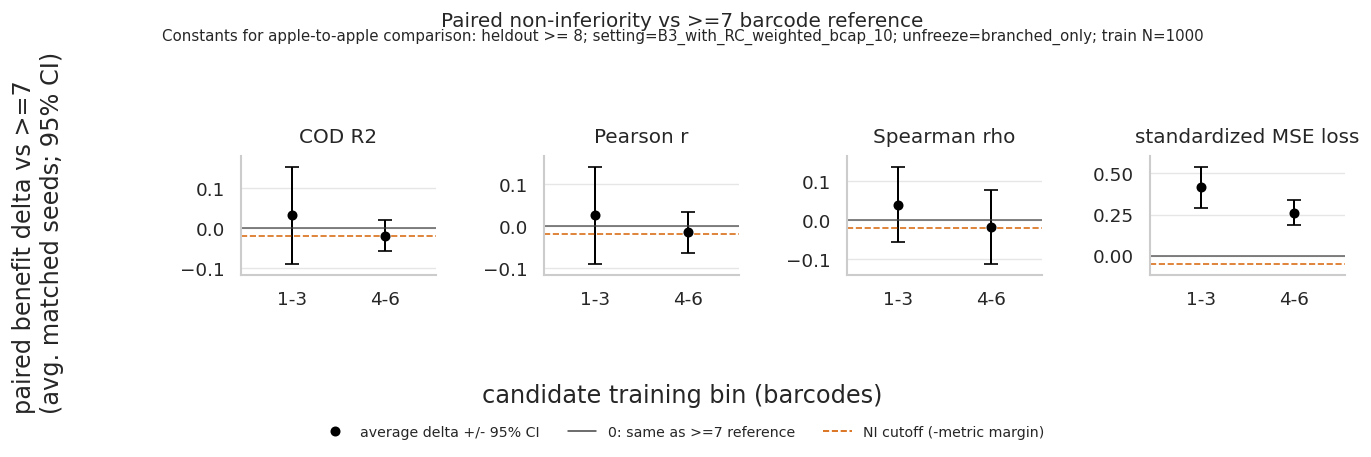

In [41]:
def plot_paired_noninferiority(
    summary,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    train_size=1000,
    metric_roots=('cod_r2', 'pearson', 'spearman', 'loss'),
    reference_label='>=7 barcodes',
    point_spacing=0.75,
):
    from matplotlib.lines import Line2D

    plot_df = summary.query(
        'heldout_min_barcodes == @heldout_min and setting == @setting and '
        'unfreeze_scope == @unfreeze_scope and train_size == @train_size'
    ).copy()
    plot_df = plot_df[plot_df['metric_root'].isin(metric_roots)]
    if plot_df.empty:
        raise ValueError('No rows after filtering.')

    metric_labels = [METRIC_SPECS[m]['label'] for m in metric_roots]
    fig, axes = plt.subplots(
        1,
        len(metric_labels),
        figsize=(2.85 * len(metric_labels), 3.75),
        sharex=False,
    )
    axes = np.atleast_1d(axes)

    for ax, metric_label in zip(axes, metric_labels):
        sub = plot_df.loc[plot_df['metric_label'] == metric_label].sort_values('candidate_label')
        if sub.empty:
            ax.set_axis_off()
            continue

        x = np.arange(len(sub), dtype=float) * point_spacing
        y = sub['mean_benefit_delta'].to_numpy()
        ci_low = sub['ci95_low'].to_numpy()
        ci_high = sub['ci95_high'].to_numpy()
        yerr = np.vstack([y - ci_low, ci_high - y])
        tick_labels = sub['candidate_label'].astype(str).str.replace(' barcodes', '', regex=False)

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt='o',
            capsize=4,
            markersize=5,
            elinewidth=1.2,
            color='black',
            label='average delta +/- 95% CI',
        )
        ax.axhline(0, color='0.25', linewidth=0.9, alpha=0.85, label=f'0: same as {reference_label}')

        margin = float(sub['margin'].iloc[0])
        ax.axhline(
            -margin,
            color='#D55E00',
            linestyle='--',
            linewidth=1.0,
            alpha=0.9,
            label='NI cutoff (-margin)',
        )

        pad = max((max(ci_high.max(), 0) - min(ci_low.min(), -margin)) * 0.12, margin * 0.75)
        ax.set_ylim(min(ci_low.min(), -margin, 0) - pad, max(ci_high.max(), 0) + pad)
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, rotation=0, ha='center')
        ax.set_xlim(x.min() - point_spacing * 0.55, x.max() + point_spacing * 0.55)
        ax.set_title(metric_label, pad=8)
        ax.set_ylabel('')
        ax.tick_params(axis='x', pad=3)
        ax.grid(axis='x', visible=False)
        ax.grid(axis='y', color='0.9', linewidth=0.8)
        ax.spines[['top', 'right']].set_visible(False)

    constants = 'heldout >= {}; setting={}; unfreeze={}; train N={}'.format(
        heldout_min, setting, unfreeze_scope, train_size
    )
    fig.suptitle('Paired non-inferiority vs >=7 barcode reference', y=0.99, fontsize=12)
    fig.text(0.5, 0.925, f'Constants for apple-to-apple comparison: {constants}', ha='center', fontsize=9)
    fig.supylabel('paired benefit delta vs >=7\n(avg. matched seeds; 95% CI)', x=0.01)
    fig.supxlabel('candidate training bin (barcodes)', y=0.11)

    legend_handles = [
        Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=5, label='average delta +/- 95% CI'),
        Line2D([0], [0], color='0.25', linewidth=0.9, label='0: same as >=7 reference'),
        Line2D([0], [0], color='#D55E00', linestyle='--', linewidth=1.0, label='NI cutoff (-metric margin)'),
    ]
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=3,
        frameon=False,
        fontsize=8.5,
    )
    fig.tight_layout(rect=(0.055, 0.18, 1.0, 0.87), w_pad=1.8)
    return fig

plot_paired_noninferiority(
    paired_test_summary,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    train_size=1000,
)
plt.show()


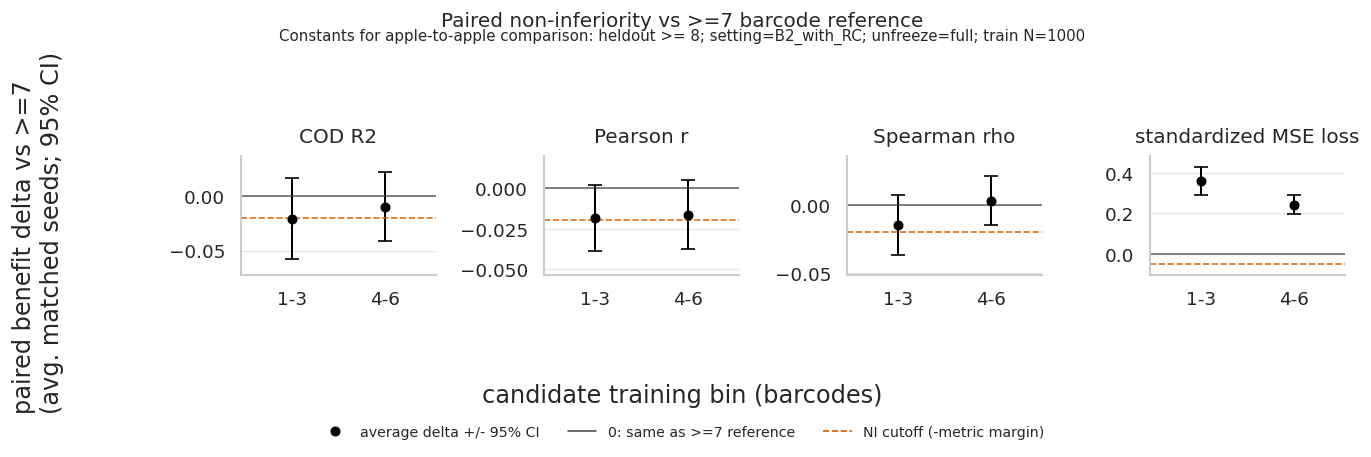

In [42]:
plot_paired_noninferiority(
    paired_test_summary,
    heldout_min=8,
    setting='B2_with_RC',
    unfreeze_scope='full',
    train_size=1000,
)
plt.show()

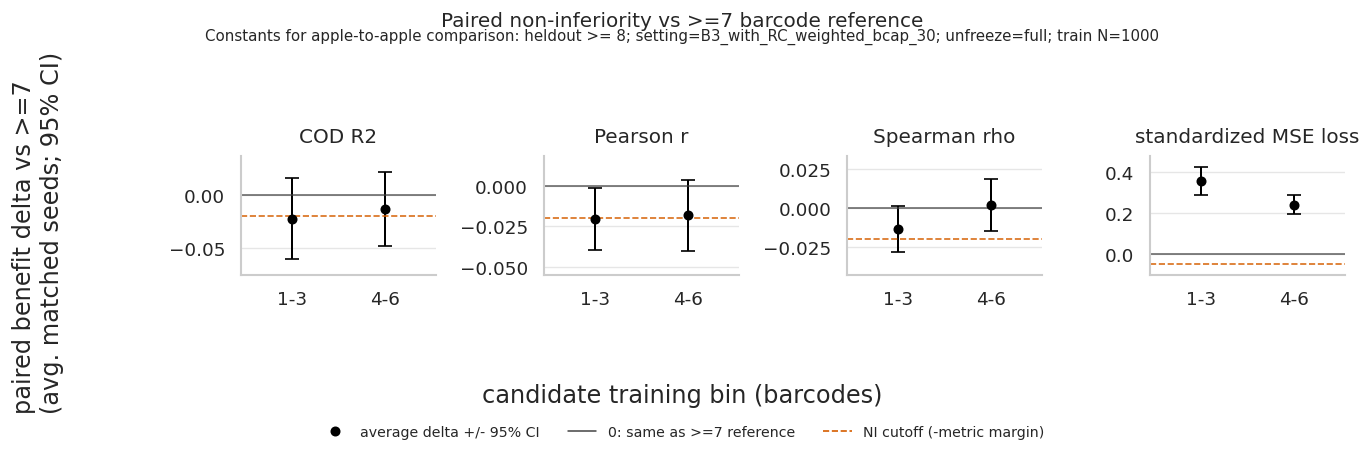

In [56]:
plot_paired_noninferiority(
    paired_test_summary,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_30',
    unfreeze_scope='full',
    train_size=1000,
)
plt.show()

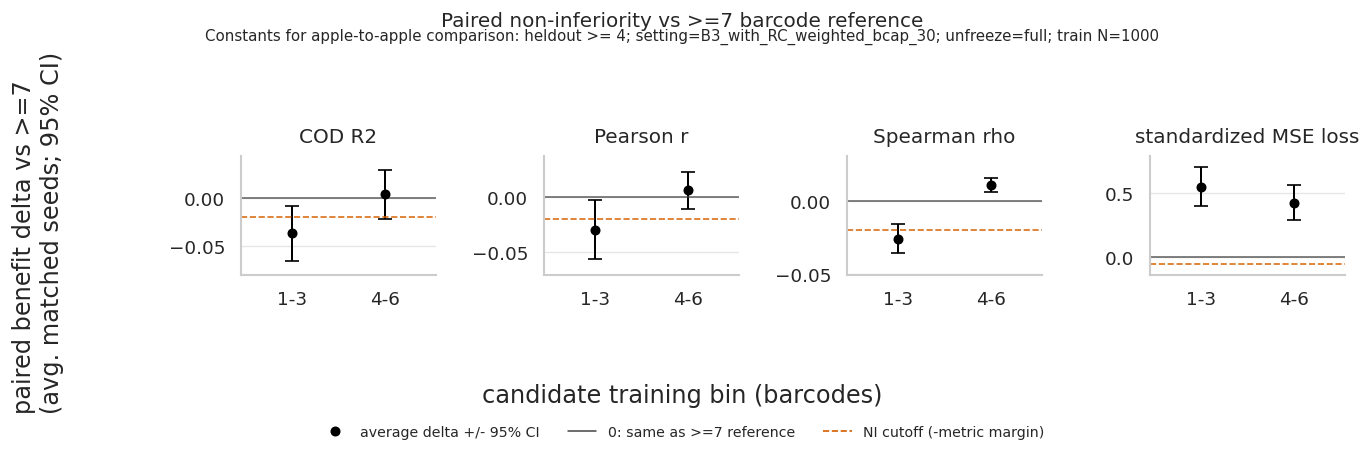

In [43]:
plot_paired_noninferiority(
    paired_test_summary,
    heldout_min=4,
    setting='B3_with_RC_weighted_bcap_30',
    unfreeze_scope='full',
    train_size=1000,
)
plt.show()

## Validation-Then-Test Discipline

For a final collaborator-facing claim, avoid choosing settings by whichever test result looks best. A conservative workflow is:

1. Use validation paired deltas to pick a modeling setting or to decide whether conclusions are robust across settings.
2. Report the heldout test paired deltas for that fixed choice.
3. Treat the `heldout >= 8` test as the stricter high-quality readout, because it evaluates only highly replicated constructs.


### Why validation first?

The test set is the final readout. If we inspect many settings and then choose the setting whose test result supports our preferred conclusion, the test set has become part of model selection. That makes the final claim optimistic, even if every individual test number was computed correctly.

For this notebook, a safer decision rule is:

1. Pick the modeling condition, or decide that the conclusion is robust across modeling conditions, using validation paired deltas only.
2. Freeze that choice. Do not re-pick it after seeing test.
3. Report heldout test paired deltas and non-inferiority calls for the frozen choice.

The paired-delta unit is one matched comparison: same seed, same split, same heldout threshold, same train size, same head, same setting, same unfreeze scope, but different training barcode bin. That pairing matters because split difficulty cancels out.

For a candidate bin `c` and reference bin `r = >=7`, define raw delta as:

`delta_raw = metric(c) - metric(r)`

For higher-is-better metrics, benefit delta is `delta_raw`. For lower-is-better loss, benefit delta is `-delta_raw`, so positive always means the candidate is better. A candidate is called non-inferior when:

`lower_95_CI(mean benefit delta) > -practical_margin`

So non-inferiority does not ask whether low barcode counts win. It asks whether the data rule out a practically meaningful loss relative to `>=7`.

### Metric math

Let `y_i` be the observed enhancer activity, `ŷ_i` the prediction, `n` the number of evaluated constructs, `mean(y)` the heldout-set mean activity, and `rank(.)` average ranks with tie handling.

`COD R2 = 1 - sum_i (y_i - ŷ_i)^2 / sum_i (y_i - mean(y))^2`

This measures absolute calibration plus accuracy on the raw target scale. It can be bad if predictions are shifted or compressed, even when ordering is decent.

`Pearson r = cov(y, ŷ) / (sd(y) * sd(ŷ))`

This measures linear association after centering and scaling. It is insensitive to additive shifts and positive multiplicative rescaling, so it can look good while COD R2 or MSE is mediocre.

`Spearman rho = Pearson r(rank(y), rank(ŷ))`

This measures monotonic ordering. It can remain good when predictions are nonlinear but ordered; it can disagree with Pearson when the relationship is monotone but curved or when a few outliers dominate linear correlation.

`standardized MSE loss = mean_i ((ŷ_i - y_i) / train_scaler_std)^2`

In the runner, predictions are inverse-transformed to raw `RNA_DNA_log10` for COD/Pearson/Spearman, while loss is computed in train-standardized target units. This makes loss useful within a fixed scaling context, but it is not a substitute for correlation/ranking if the biological objective is prioritizing constructs.


In [44]:
# Compare validation and test non-inferiority calls side by side at full N.
val_full = paired_val_summary.query('train_size == 1000').copy()
test_full = paired_test_summary.query('train_size == 1000').copy()

join_keys = [
    'heldout_min_barcodes', 'setting', 'init_head', 'unfreeze_scope',
    'candidate_bin', 'candidate_label', 'reference_bin', 'reference_label',
    'metric_root', 'metric_label',
]
val_test_compare = val_full.merge(
    test_full,
    on=join_keys,
    suffixes=('_val', '_test'),
)

val_test_display = val_test_compare.sort_values([
    'heldout_min_barcodes', 'setting', 'unfreeze_scope', 'metric_root', 'candidate_bin'
])
display(val_test_display[[
    'heldout_min_barcodes', 'setting', 'unfreeze_scope', 'metric_label', 'candidate_label',
    'mean_benefit_delta_val', 'ci95_low_val', 'noninferior_95ci_val',
    'mean_benefit_delta_test', 'ci95_low_test', 'noninferior_95ci_test',
    'margin_test',
]])


,heldout_min_barcodes,setting,unfreeze_scope,metric_label,candidate_label,mean_benefit_delta_val,ci95_low_val,noninferior_95ci_val,mean_benefit_delta_test,ci95_low_test,noninferior_95ci_test,margin_test
0,4,B2_with_RC,branched_only,COD R2,1-3 barcodes,0.001229,-0.023445,False,-0.030106,-0.066833,False,0.02
4,4,B2_with_RC,branched_only,COD R2,4-6 barcodes,0.017298,-0.008251,True,0.000240,-0.034814,False,0.02
1,4,B2_with_RC,branched_only,standardized MSE loss,1-3 barcodes,0.548996,0.437499,True,0.553576,0.399983,True,0.05
5,4,B2_with_RC,branched_only,standardized MSE loss,4-6 barcodes,0.417702,0.301851,True,0.422706,0.286774,True,0.05
2,4,B2_with_RC,branched_only,Pearson r,1-3 barcodes,0.003719,-0.024059,False,-0.021707,-0.067296,False,0.02
6,4,B2_with_RC,branched_only,Pearson r,4-6 barcodes,0.017670,-0.007246,True,-0.008262,-0.046269,False,0.02
3,4,B2_with_RC,branched_only,Spearman rho,1-3 barcodes,-0.005288,-0.042922,False,-0.025608,-0.052726,False,0.02
7,4,B2_with_RC,branched_only,Spearman rho,4-6 barcodes,0.029555,-0.020471,False,0.004048,-0.014891,True,0.02
8,4,B2_with_RC,full,COD R2,1-3 barcodes,-0.022761,-0.055235,False,-0.044109,-0.074938,False,0.02
12,4,B2_with_RC,full,COD R2,4-6 barcodes,-0.005213,-0.021151,False,0.002206,-0.027409,False,0.02


In [45]:
# Find cases where metrics disagree on the heldout test non-inferiority call.
call_index = [
    'heldout_min_barcodes', 'setting', 'init_head', 'unfreeze_scope',
    'candidate_bin', 'candidate_label', 'reference_bin', 'reference_label',
]
test_call_matrix = (
    val_test_compare
    .pivot_table(
        index=call_index,
        columns='metric_label',
        values='noninferior_95ci_test',
        aggfunc='first',
        observed=True,
    )
    .reset_index()
)
metric_cols = [c for c in test_call_matrix.columns if c not in call_index]
test_call_matrix['n_test_metrics_noninferior'] = test_call_matrix[metric_cols].sum(axis=1)
test_call_matrix['has_metric_disagreement'] = test_call_matrix[metric_cols].nunique(axis=1) > 1

display(
    test_call_matrix
    .query('has_metric_disagreement')
    .sort_values(['heldout_min_barcodes', 'setting', 'unfreeze_scope', 'candidate_bin'])
)


metric_label,heldout_min_barcodes,setting,init_head,unfreeze_scope,candidate_bin,candidate_label,reference_bin,reference_label,COD R2,Pearson r,Spearman rho,standardized MSE loss,n_test_metrics_noninferior,has_metric_disagreement
0,4,B2_with_RC,K562,branched_only,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,False,False,False,True,1,True
1,4,B2_with_RC,K562,branched_only,bc_4_6,4-6 barcodes,bc_ge7,>=7 barcodes,False,False,True,True,2,True
2,4,B2_with_RC,K562,full,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,False,False,False,True,1,True
3,4,B2_with_RC,K562,full,bc_4_6,4-6 barcodes,bc_ge7,>=7 barcodes,False,True,True,True,3,True
4,4,B3_with_RC_weighted_bcap_10,K562,branched_only,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,False,False,False,True,1,True
5,4,B3_with_RC_weighted_bcap_10,K562,branched_only,bc_4_6,4-6 barcodes,bc_ge7,>=7 barcodes,False,False,True,True,2,True
6,4,B3_with_RC_weighted_bcap_10,K562,full,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,False,False,False,True,1,True
7,4,B3_with_RC_weighted_bcap_10,K562,full,bc_4_6,4-6 barcodes,bc_ge7,>=7 barcodes,False,True,True,True,3,True
8,4,B3_with_RC_weighted_bcap_30,K562,branched_only,bc_1_3,1-3 barcodes,bc_ge7,>=7 barcodes,False,False,False,True,1,True
9,4,B3_with_RC_weighted_bcap_30,K562,branched_only,bc_4_6,4-6 barcodes,bc_ge7,>=7 barcodes,False,False,True,True,2,True


## Prediction-Level Parity Diagnostics

The aggregate CSVs contain metric summaries, while the per-run cache payloads also contain `pred_df` for the heldout test split. The helpers below load those cached test predictions and make predicted-vs-actual plots for one frozen modeling condition.

Use this when metrics disagree. A few common patterns to look for:

- High Pearson/Spearman but weak COD R2: points follow an ordered trend, but the cloud is shifted, compressed, or expanded relative to the `y = x` line.
- Good standardized loss but weak rank metrics: predictions are close in absolute value on average, but they do not order constructs well.
- Pearson stronger than Spearman: linear trend is helped by high-leverage points, or rank ordering is noisy among the middle mass.
- Spearman stronger than Pearson: monotone ordering is present, but the raw relationship is nonlinear or heteroscedastic.

Current cache note: this run saved test `pred_df` in each run payload. It did not save validation `pred_df`, so validation-vs-test parity plots would require re-evaluating models or changing the runner to cache validation predictions too.


,seed,train_barcode_bin_label,n,cod_r2,pearson,spearman,loss_standardized
0,23,1-3 barcodes,123.0,0.227167,0.512144,0.401102,0.403295
1,23,4-6 barcodes,123.0,0.258561,0.555809,0.454987,0.520199
2,23,>=7 barcodes,123.0,0.225963,0.515982,0.397797,0.855617


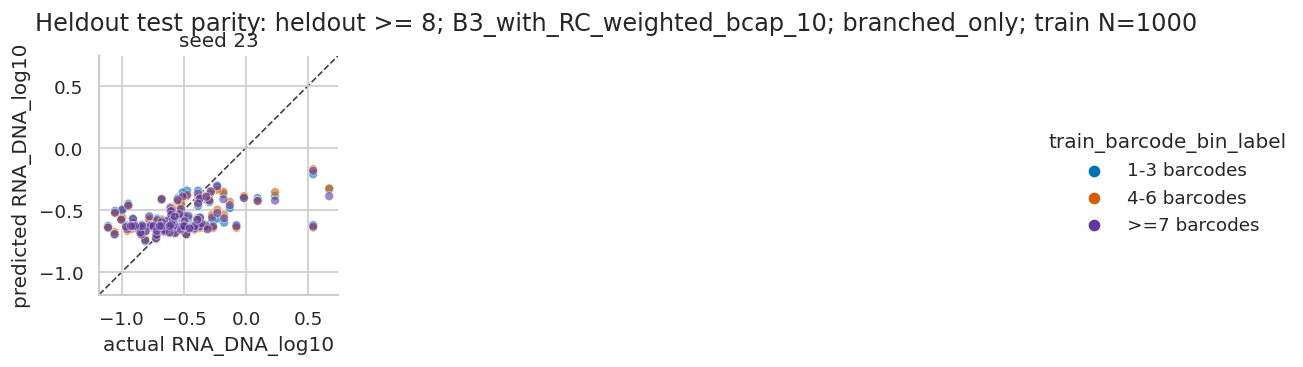

In [46]:
import pickle


def find_cached_run_payload(row):
    seed = int(row['seed'])
    heldout_min = int(row['heldout_min_barcodes'])
    train_size = int(row['train_size'])
    cache_root = RUN_DIR / 'per_seed' / f'seed_{seed}' / 'cache' / 'runs'
    if not cache_root.exists():
        raise FileNotFoundError(f'No cache directory for seed {seed}: {cache_root}')

    required_tokens = [
        f'heldout_minbc{heldout_min}',
        f'seed{seed}__heldoutbc{heldout_min}__head{row["init_head"]}',
        f'__{row["setting"]}__',
        f'__bin{row["train_barcode_bin"]}__n{train_size}__',
        f'__{row["unfreeze_scope"]}__{row["train_sampling_mode"]}__',
    ]
    matches = [
        p for p in sorted(cache_root.rglob('*.pkl'))
        if all(token in str(p) for token in required_tokens)
    ]
    if len(matches) != 1:
        raise FileNotFoundError(
            f'Expected one cache payload, found {len(matches)} for tokens: {required_tokens}'
        )
    return matches[0]


def load_test_predictions_for_row(row):
    payload_path = find_cached_run_payload(row)
    with payload_path.open('rb') as fh:
        payload = pickle.load(fh)
    pred_df = payload['pred_df'].copy()
    pred_df['seed'] = int(row['seed'])
    pred_df['heldout_min_barcodes'] = int(row['heldout_min_barcodes'])
    pred_df['setting'] = row['setting']
    pred_df['init_head'] = row['init_head']
    pred_df['unfreeze_scope'] = row['unfreeze_scope']
    pred_df['train_size'] = int(row['train_size'])
    pred_df['train_barcode_bin'] = row['train_barcode_bin']
    pred_df['train_barcode_bin_label'] = row['train_barcode_bin_label']
    pred_df['target_scaler_mean'] = float(row['target_scaler_mean'])
    pred_df['target_scaler_std'] = float(row['target_scaler_std'])
    pred_df['payload_path'] = str(payload_path)
    return pred_df


def load_test_prediction_panel(
    runs,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    init_head='K562',
    train_size=1000,
    seeds=None,
):
    rows = runs.query(
        'heldout_min_barcodes == @heldout_min and setting == @setting and '
        'unfreeze_scope == @unfreeze_scope and init_head == @init_head and '
        'train_size == @train_size'
    ).copy()
    if seeds is not None:
        rows = rows[rows['seed'].isin(seeds)]
    rows = rows.sort_values(['seed', 'train_barcode_bin_sort_order'])
    if rows.empty:
        raise ValueError('No run rows matched the requested parity-plot filters.')
    return pd.concat([load_test_predictions_for_row(row) for _, row in rows.iterrows()], ignore_index=True)


def metrics_from_prediction_frame(pred_df, target_col='RNA_DNA_log10', pred_col='pred'):
    y = pred_df[target_col].to_numpy(dtype=float)
    yhat = pred_df[pred_col].to_numpy(dtype=float)
    scaler_std = float(pred_df['target_scaler_std'].iloc[0])
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    pearson = stats.pearsonr(y, yhat)[0] if np.std(y) > 1e-8 and np.std(yhat) > 1e-8 else np.nan
    spearman = stats.spearmanr(y, yhat)[0] if np.std(y) > 1e-8 and np.std(yhat) > 1e-8 else np.nan
    return pd.Series({
        'n': len(pred_df),
        'cod_r2': np.nan if ss_tot < 1e-8 else 1.0 - ss_res / ss_tot,
        'pearson': pearson,
        'spearman': spearman,
        'loss_standardized': np.mean(((yhat - y) / scaler_std) ** 2),
    })


def plot_test_prediction_parity(pred_panel, target_col='RNA_DNA_log10', pred_col='pred', sample_per_group=None):
    plot_df = pred_panel.copy()
    if sample_per_group is not None:
        plot_df = (
            plot_df.groupby(['seed', 'train_barcode_bin_label'], observed=True, group_keys=False)
            .apply(lambda x: x.sample(min(len(x), sample_per_group), random_state=0))
        )

    metric_summary = (
        pred_panel.groupby(['seed', 'train_barcode_bin_label'], observed=True)
        .apply(metrics_from_prediction_frame, target_col=target_col, pred_col=pred_col)
        .reset_index()
    )
    metric_summary['train_barcode_bin_label'] = pd.Categorical(
        metric_summary['train_barcode_bin_label'], categories=BIN_LABEL_ORDER, ordered=True
    )
    metric_summary = metric_summary.sort_values(['seed', 'train_barcode_bin_label'])

    g = sns.relplot(
        data=plot_df,
        x=target_col,
        y=pred_col,
        hue='train_barcode_bin_label',
        hue_order=BIN_LABEL_ORDER,
        palette=BIN_PALETTE,
        col='seed',
        col_wrap=3,
        kind='scatter',
        alpha=0.60,
        s=28,
        height=3.1,
        aspect=1.0,
    )
    lim_low = min(plot_df[target_col].min(), plot_df[pred_col].min())
    lim_high = max(plot_df[target_col].max(), plot_df[pred_col].max())
    pad = 0.04 * (lim_high - lim_low)
    lims = (lim_low - pad, lim_high + pad)
    for ax in g.axes.flat:
        ax.plot(lims, lims, color='0.25', lw=1, ls='--', zorder=0)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal', adjustable='box')
    g.set_axis_labels('actual RNA_DNA_log10', 'predicted RNA_DNA_log10')
    g.set_titles(col_template='seed {col_name}')
    g.fig.subplots_adjust(top=0.86)
    first = pred_panel.iloc[0]
    g.fig.suptitle(
        'Heldout test parity: heldout >= {}; {}; {}; train N={}'.format(
            int(first['heldout_min_barcodes']), first['setting'], first['unfreeze_scope'], int(first['train_size'])
        )
    )
    return g, metric_summary


# Example: one seed keeps the visual readable; use seeds=None to facet all seeds.
test_pred_panel = load_test_prediction_panel(
    runs,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    init_head='K562',
    train_size=1000,
    seeds=[23],
)
g, parity_metric_summary = plot_test_prediction_parity(test_pred_panel)
display(parity_metric_summary)
plt.show()


## Barcode-Budget-Normalized View

Equal `train_size` compares the same number of sequence variants. The experimental-budget question is different: lower barcode-count constructs may let collaborators include more variants for a fixed barcode/sequencing budget.

As a first approximation, define:

`estimated_barcode_budget = train_size * train_barcode_mean`

This uses the actual sampled training set's mean barcode count. It is not a full sequencing-cost model, but it gives a more relevant x-axis than construct count alone.


In [47]:
runs_budget = runs.copy()
runs_budget['estimated_barcode_budget'] = runs_budget['train_size'] * runs_budget['train_barcode_mean']
runs_budget['variants_per_1000_barcodes'] = 1000.0 / runs_budget['train_barcode_mean']

budget_summary = (
    runs_budget.groupby([
        'heldout_min_barcodes', 'train_barcode_bin', 'train_barcode_bin_label', 'train_size'
    ], observed=True, dropna=False)
    .agg(
        mean_barcode_count=('train_barcode_mean', 'mean'),
        sd_barcode_count=('train_barcode_mean', 'std'),
        mean_estimated_budget=('estimated_barcode_budget', 'mean'),
        variants_per_1000_barcodes=('variants_per_1000_barcodes', 'mean'),
        n=('train_barcode_mean', 'count'),
    )
    .reset_index()
    .sort_values(['heldout_min_barcodes', 'train_barcode_bin', 'train_size'])
)
display(budget_summary)


,heldout_min_barcodes,train_barcode_bin,train_barcode_bin_label,train_size,mean_barcode_count,sd_barcode_count,mean_estimated_budget,variants_per_1000_barcodes,n
0,4,bc_1_3,1-3 barcodes,250,2.027200,0.035783,506.8,493.440947,30
1,4,bc_1_3,1-3 barcodes,500,2.026400,0.019948,1013.2,493.532064,30
2,4,bc_1_3,1-3 barcodes,750,2.025333,0.015885,1519.0,493.775355,30
3,4,bc_1_3,1-3 barcodes,1000,2.035000,0.000000,2035.0,491.400491,30
4,4,bc_4_6,4-6 barcodes,250,4.886400,0.038476,1221.6,204.661928,30
5,4,bc_4_6,4-6 barcodes,500,4.886800,0.025066,2443.4,204.638084,30
6,4,bc_4_6,4-6 barcodes,750,4.895467,0.030112,3671.6,204.278068,30
7,4,bc_4_6,4-6 barcodes,1000,4.894800,0.014533,4894.8,204.300178,30
8,4,bc_ge7,>=7 barcodes,250,11.244000,0.200187,2811.0,88.963765,30
9,4,bc_ge7,>=7 barcodes,500,11.223600,0.192471,5611.8,89.123484,30


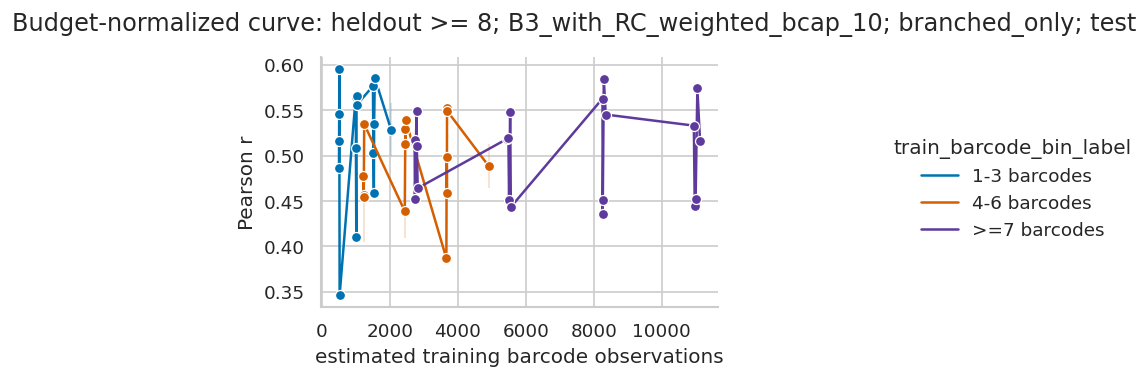

In [48]:
def plot_budget_normalized_curves(
    frame,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    split='test',
    metric_root='pearson',
):
    metric_col = METRIC_SPECS[metric_root]['cols'][split]
    plot_df = frame.query(
        'heldout_min_barcodes == @heldout_min and setting == @setting and '
        'unfreeze_scope == @unfreeze_scope'
    ).copy()
    if plot_df.empty:
        raise ValueError('No rows after filtering.')

    g = sns.relplot(
        data=plot_df,
        x='estimated_barcode_budget',
        y=metric_col,
        hue='train_barcode_bin_label',
        hue_order=BIN_LABEL_ORDER,
        palette=BIN_PALETTE,
        kind='line',
        marker='o',
        estimator='mean',
        errorbar='se',
        height=3.2,
        aspect=1.45,
    )
    g.set_axis_labels('estimated training barcode observations', METRIC_SPECS[metric_root]['label'])
    g.fig.subplots_adjust(top=0.86)
    g.fig.suptitle(
        'Budget-normalized curve: heldout >= {}; {}; {}; {}'.format(
            heldout_min, setting, unfreeze_scope, split
        )
    )
    return g

plot_budget_normalized_curves(
    runs_budget,
    heldout_min=8,
    setting='B3_with_RC_weighted_bcap_10',
    unfreeze_scope='branched_only',
    split='test',
    metric_root='pearson',
)
plt.show()


In [49]:
def interpolate_curves_at_budgets(
    frame,
    budgets,
    split='test',
    metric_root='pearson',
):
    metric_col = METRIC_SPECS[metric_root]['cols'][split]
    group_cols = [
        'heldout_min_barcodes', 'seed', 'setting', 'init_head', 'unfreeze_scope',
        'train_sampling_mode', 'train_barcode_bin', 'train_barcode_bin_label',
    ]
    rows = []
    for keys, group in frame.groupby(group_cols, observed=True, dropna=False):
        group = group.sort_values('estimated_barcode_budget')
        x = group['estimated_barcode_budget'].to_numpy(dtype=float)
        y = group[metric_col].to_numpy(dtype=float)
        if len(x) < 2:
            continue
        for budget in budgets:
            if budget < np.nanmin(x) or budget > np.nanmax(x):
                continue
            row = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
            row['budget'] = float(budget)
            row['split'] = split
            row['metric_root'] = metric_root
            row['metric_label'] = METRIC_SPECS[metric_root]['label']
            row['value_interp'] = float(np.interp(budget, x, y))
            rows.append(row)
    return pd.DataFrame(rows)

# Example shared budgets. Edit after inspecting budget_summary.
common_budgets = [1000, 2000, 3000, 5000]
budget_interp = interpolate_curves_at_budgets(runs_budget, common_budgets, split='test', metric_root='pearson')

display(
    budget_interp.groupby([
        'heldout_min_barcodes', 'budget', 'setting', 'unfreeze_scope',
        'train_barcode_bin', 'train_barcode_bin_label'
    ], observed=True, dropna=False)
    .agg(mean_value=('value_interp', 'mean'), se_value=('value_interp', lambda x: x.std(ddof=1) / np.sqrt(x.count())), n=('value_interp', 'count'))
    .reset_index()
    .sort_values(['heldout_min_barcodes', 'budget', 'setting', 'unfreeze_scope', 'train_barcode_bin'])
)


,heldout_min_barcodes,budget,setting,unfreeze_scope,train_barcode_bin,train_barcode_bin_label,mean_value,se_value,n
0,4,1000.0,B2_with_RC,branched_only,bc_1_3,1-3 barcodes,0.441943,0.030846,5
1,4,1000.0,B2_with_RC,full,bc_1_3,1-3 barcodes,0.429155,0.022865,5
2,4,1000.0,B3_with_RC_weighted_bcap_10,branched_only,bc_1_3,1-3 barcodes,0.446105,0.028716,5
3,4,1000.0,B3_with_RC_weighted_bcap_10,full,bc_1_3,1-3 barcodes,0.433371,0.023492,5
4,4,1000.0,B3_with_RC_weighted_bcap_30,branched_only,bc_1_3,1-3 barcodes,0.446105,0.028716,5
5,4,1000.0,B3_with_RC_weighted_bcap_30,full,bc_1_3,1-3 barcodes,0.433554,0.023521,5
6,4,2000.0,B2_with_RC,branched_only,bc_1_3,1-3 barcodes,0.465080,0.028236,5
7,4,2000.0,B2_with_RC,branched_only,bc_4_6,4-6 barcodes,0.455453,0.020038,5
8,4,2000.0,B2_with_RC,full,bc_1_3,1-3 barcodes,0.447838,0.021883,5
9,4,2000.0,B2_with_RC,full,bc_4_6,4-6 barcodes,0.458190,0.021618,5


## Confounder Diagnostics

Barcode count is probably not randomized. It may correlate with construct properties or measurement properties. For example, some sequence classes may synthesize, clone, map, amplify, or express differently, causing barcode count to vary. If those properties also affect prediction difficulty, then a low-vs-high barcode comparison can partly reflect construct distribution differences rather than barcode count alone.

This section checks simple proxies available in the run and raw data:

- Training target mean and standard deviation, using the train-only scaler metadata.
- Barcode-count distribution inside sampled training sets.
- Raw-data target distribution by barcode bin.
- Design-part columns, if available.


,heldout_min_barcodes,train_barcode_bin,train_barcode_bin_label,setting,unfreeze_scope,train_size,target_mean_mean,target_mean_sd,target_std_mean,target_std_sd,train_barcode_mean,train_hq_fraction,n
8,4,bc_1_3,1-3 barcodes,B3_with_RC_weighted_bcap_10,branched_only,250,-0.549290,0.011648,0.391879,0.025422,2.027200,0.000000,5
9,4,bc_1_3,1-3 barcodes,B3_with_RC_weighted_bcap_10,branched_only,500,-0.549629,0.008493,0.394893,0.010360,2.026400,0.000000,5
10,4,bc_1_3,1-3 barcodes,B3_with_RC_weighted_bcap_10,branched_only,750,-0.549358,0.005613,0.404188,0.007687,2.025333,0.000000,5
11,4,bc_1_3,1-3 barcodes,B3_with_RC_weighted_bcap_10,branched_only,1000,-0.547772,0.000000,0.409285,0.000000,2.035000,0.000000,5
32,4,bc_4_6,4-6 barcodes,B3_with_RC_weighted_bcap_10,branched_only,250,-0.607626,0.011633,0.371740,0.017658,4.886400,1.000000,5
33,4,bc_4_6,4-6 barcodes,B3_with_RC_weighted_bcap_10,branched_only,500,-0.593656,0.012652,0.364061,0.007904,4.886800,1.000000,5
34,4,bc_4_6,4-6 barcodes,B3_with_RC_weighted_bcap_10,branched_only,750,-0.594538,0.006552,0.364599,0.007072,4.895467,1.000000,5
35,4,bc_4_6,4-6 barcodes,B3_with_RC_weighted_bcap_10,branched_only,1000,-0.591843,0.001630,0.361343,0.004084,4.894800,1.000000,5
56,4,bc_ge7,>=7 barcodes,B3_with_RC_weighted_bcap_10,branched_only,250,-0.563723,0.008052,0.297258,0.018920,11.244000,1.000000,5
57,4,bc_ge7,>=7 barcodes,B3_with_RC_weighted_bcap_10,branched_only,500,-0.578144,0.010506,0.289016,0.011902,11.223600,1.000000,5


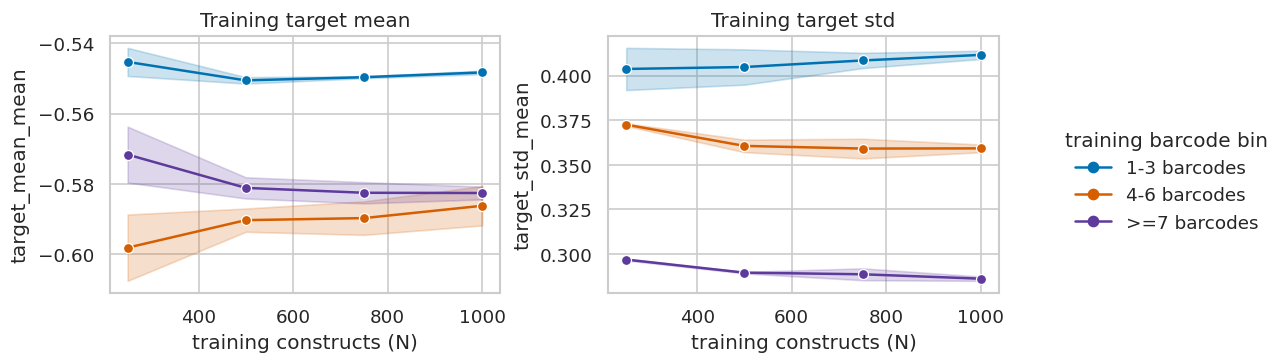

In [50]:
# Target distribution proxy from each training set's scaler.
from matplotlib.lines import Line2D

scaler_summary = (
    runs.groupby([
        'heldout_min_barcodes', 'train_barcode_bin', 'train_barcode_bin_label',
        'setting', 'unfreeze_scope', 'train_size'
    ], observed=True, dropna=False)
    .agg(
        target_mean_mean=('target_scaler_mean', 'mean'),
        target_mean_sd=('target_scaler_mean', 'std'),
        target_std_mean=('target_scaler_std', 'mean'),
        target_std_sd=('target_scaler_std', 'std'),
        train_barcode_mean=('train_barcode_mean', 'mean'),
        train_hq_fraction=('train_hq_fraction', 'mean'),
        n=('seed', 'count'),
    )
    .reset_index()
)

display(scaler_summary.query('setting == "B3_with_RC_weighted_bcap_10" and unfreeze_scope == "branched_only"'))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2), sharex=True)
plot_df = scaler_summary.query('setting == "B3_with_RC_weighted_bcap_10" and unfreeze_scope == "branched_only"').copy()
sns.lineplot(
    data=plot_df,
    x='train_size', y='target_mean_mean', hue='train_barcode_bin_label',
    hue_order=BIN_LABEL_ORDER, palette=BIN_PALETTE, marker='o', ax=axes[0], legend=False
)
sns.lineplot(
    data=plot_df,
    x='train_size', y='target_std_mean', hue='train_barcode_bin_label',
    hue_order=BIN_LABEL_ORDER, palette=BIN_PALETTE, marker='o', ax=axes[1], legend=False
)
axes[0].set_title('Training target mean')
axes[1].set_title('Training target std')
for ax in axes:
    ax.set_xlabel('training constructs (N)')

legend_handles = [
    Line2D([0], [0], color=BIN_PALETTE[label], marker='o', label=label)
    for label in BIN_LABEL_ORDER
]
fig.legend(
    handles=legend_handles,
    title='training barcode bin',
    loc='center left',
    bbox_to_anchor=(0.84, 0.5),
    frameon=False,
)
fig.tight_layout(rect=(0, 0, 0.82, 1))
plt.show()


,comparable_barcode_bin,n,barcode_mean,barcode_median,dna_counts_mean,rna_counts_mean,target_mean,target_std
0,1-3 barcodes,1852,2.022678,2.0,47.986501,16.489201,-0.548282,0.418969
1,4-6 barcodes,1396,4.906160,5.0,100.724928,34.844556,-0.589166,0.361948
2,>=7 barcodes,1540,15.090260,10.0,315.924675,102.712987,-0.579985,0.286776


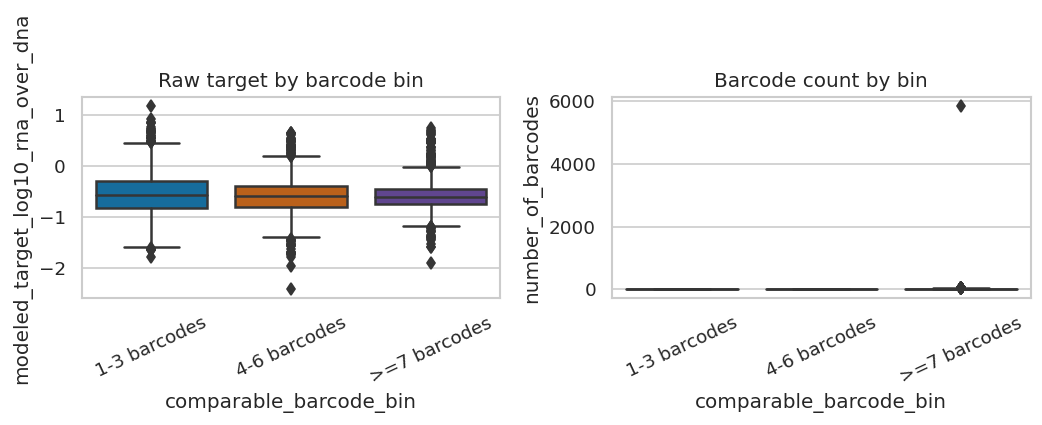

In [51]:
raw = pd.read_csv(DATA_PATH)
raw = raw.copy()
raw['modeled_target_log10_rna_over_dna'] = np.log10(raw['RNA_bc_counts_sum'] / raw['DNA_bc_counts_sum'])

bc = pd.to_numeric(raw['number_of_barcodes'], errors='coerce')
raw['comparable_barcode_bin'] = np.select(
    [bc.between(1, 3), bc.between(4, 6), bc >= 7],
    ['1-3 barcodes', '4-6 barcodes', '>=7 barcodes'],
    default=np.nan,
)
raw['comparable_barcode_bin'] = pd.Categorical(raw['comparable_barcode_bin'], categories=BIN_LABEL_ORDER, ordered=True)

raw_bin_summary = (
    raw.groupby('comparable_barcode_bin', observed=True, dropna=False)
    .agg(
        n=('number_of_barcodes', 'count'),
        barcode_mean=('number_of_barcodes', 'mean'),
        barcode_median=('number_of_barcodes', 'median'),
        dna_counts_mean=('DNA_bc_counts_sum', 'mean'),
        rna_counts_mean=('RNA_bc_counts_sum', 'mean'),
        target_mean=('modeled_target_log10_rna_over_dna', 'mean'),
        target_std=('modeled_target_log10_rna_over_dna', 'std'),
    )
    .reset_index()
)
display(raw_bin_summary)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
sns.boxplot(
    data=raw, x='comparable_barcode_bin', y='modeled_target_log10_rna_over_dna',
    order=BIN_LABEL_ORDER, palette=BIN_PALETTE, ax=axes[0]
)
sns.boxplot(
    data=raw, x='comparable_barcode_bin', y='number_of_barcodes',
    order=BIN_LABEL_ORDER, palette=BIN_PALETTE, ax=axes[1]
)
axes[0].set_title('Raw target by barcode bin')
axes[1].set_title('Barcode count by bin')
for ax in axes:
    ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
plt.show()


In [52]:
# Simple design-part balance checks, if these columns carry multiple categories.
factor_cols = [col for col in ['Promoter', 'FivePrime', 'Intron', 'ThreePrime'] if col in raw.columns]
for col in factor_cols:
    nunique = raw[col].nunique(dropna=False)
    print()
    print('{}: {} unique values'.format(col, nunique))
    if nunique <= 30:
        tab = pd.crosstab(raw['comparable_barcode_bin'], raw[col], normalize='index', dropna=False)
        display(tab)
    else:
        # For long sequence-valued factors, summarize counts and show the largest categories.
        top_values = raw[col].astype(str).value_counts(dropna=False).head(10).index
        tab = pd.crosstab(
            raw['comparable_barcode_bin'],
            raw[col].astype(str).where(raw[col].astype(str).isin(top_values), other='OTHER'),
            normalize='index',
            dropna=False,
        )
        display(tab)



Promoter: 1 unique values


Promoter,GGGAGGTCTATATAAGCAGAGCTCAGTTAGTGAACCGTCAGA
comparable_barcode_bin,
1-3 barcodes,1.0
4-6 barcodes,1.0
>=7 barcodes,1.0



FivePrime: 1 unique values


FivePrime,GCAAGCCATATGGTTCCAGGAAAGTTTTGTGCCGCTCAGAACTGAGCGGA
comparable_barcode_bin,
1-3 barcodes,1.0
4-6 barcodes,1.0
>=7 barcodes,1.0



Intron: 1 unique values


Intron,x
comparable_barcode_bin,
1-3 barcodes,1.0
4-6 barcodes,1.0
>=7 barcodes,1.0



ThreePrime: 1 unique values


ThreePrime,x
comparable_barcode_bin,
1-3 barcodes,1.0
4-6 barcodes,1.0
>=7 barcodes,1.0


## Follow-Up Exact-Bin Run, If Needed

The current run intentionally pools `1-3` barcodes to get a stable low-barcode training pool of 1000 constructs. That is good for the broad question: low barcode counts vs higher barcode counts.

It can hide a threshold effect. For example, exactly 1 barcode might be bad while 2-3 barcodes might be fine. A matched-cap follow-up would split exact or narrower bins and lower the cap so each bin can be compared at the same N, for example:

- `1 barcode`
- `2 barcodes`
- `3 barcodes`
- `4-6 barcodes`
- `>=7 barcodes`

If the exact 1-barcode pool has only about 500-600 constructs, set `train_pool_cap=500` and compare sizes like `125, 250, 375, 500`. This would answer "how low can we go?" more directly than the current `1-3` pooled result.


## Suggested Decision Language

A strong collaborator-facing conclusion would look like this:

- At equal training construct count (`N`), `1-3` or `4-6` barcode training is within the pre-specified practical margin of `>=7` barcode training on the high-quality heldout test set.
- This statement is based on paired deltas within identical seed/split/test-set conditions, not independent SE-band overlap.
- The conclusion is robust across the chosen modeling setting, or the modeling setting was chosen by validation before looking at test.
- Under a barcode-budget x-axis, the lower barcode bins are at least competitive, meaning the experiment can recover more sequence variants for the same approximate barcode budget.
- Remaining caveat: barcode count may correlate with construct families or target distribution, so the recommendation is strongest if the confounder diagnostics look balanced or the downstream library will have a similar design distribution.
